In [ ]:
# •	File name: Evolv1-Hourly Divided loads and index calculations
# •	Author: Ehsan Akbari
# •	Affiliation: University of Waterloo, PhD student.


In [1]:
import torch 
from torch import nn 
from torch.utils.data import DataLoader
import numpy as np 
import dask.dataframe as dd
import pandas as pd  
import glob
import os 
import matplotlib.pyplot as plt   
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
#Whole building loads:
Data = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Total_Energy_Consumption(kWh).csv', encoding='latin-1')   
Data = pd.DataFrame(Data)
Data1 = Data.drop('Date', axis=1) 
Data_1 = Data1.values

Data2 = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Whole_EV_consumption(kWh).csv', encoding='latin-1')
Data2 = pd.DataFrame(Data2)
EV_consumption_DF=Data2
Data_2 = Data2.drop('Date', axis=1) 
Data_2 = Data_2.values

Temp = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Outside_ Temperature.csv', encoding='latin-1')
Temp = pd.DataFrame(Temp)
Temp2 = Temp.drop('Date', axis=1) 
Temp_2 = Temp2.values
print (Temp_2.shape)

Radiation = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Whole_PV_Generation(kWh).csv', encoding='latin-1')
Radiation = pd.DataFrame(Radiation)
Radiation2 = Radiation.drop('Date', axis=1) 
Radiation_2 = Radiation2.values
Radiation_2.shape


Data_new = Data_1-Data_2
Radiation_2.shape

(1095, 24)


(1095, 24)

In [89]:
Total_consumption=pd.DataFrame(Data)

Total_consumption_2021=Total_consumption.iloc[Total_consumption[Total_consumption["Date"]=='1/1/2021'].index[0]:
                                 Total_consumption[Total_consumption["Date"]=='12/31/2021'].index[0]+1]
consumption_2021=Total_consumption_2021.drop('Date', axis=1)
consumption_2021=consumption_2021.values

Total_consumption_2022=Total_consumption.iloc[Total_consumption[Total_consumption["Date"]=='1/1/2022'].index[0]:
                                 Total_consumption[Total_consumption["Date"]=='12/31/2022'].index[0]+1]
Total_consumption_2022=Total_consumption_2022.reset_index(drop=True)
consumption_2022=Total_consumption_2022.drop('Date', axis=1)
consumption_2022=consumption_2022.values

Total_consumption_2023=Total_consumption.iloc[Total_consumption[Total_consumption["Date"]=='1/1/2023'].index[0]:
                                 Total_consumption[Total_consumption["Date"]=='12/31/2023'].index[0]+1]
Total_consumption_2023=Total_consumption_2023.reset_index(drop=True)
consumption_2023=Total_consumption_2023.drop('Date', axis=1)
consumption_2023=consumption_2023.values

Total_consumption_2023

,Date,0:00 - 0:59am,1:00 - 1:59am,2:00 - 2:59am,3:00 - 3:59am,4:00 - 4:59am,5:00 - 5:59am,6:00 - 6:59am,7:00 - 7:59am,8:00 - 8:59am,...,2:00 - 2:59pm,3:00 - 3:59pm,4:00 - 4:59pm,5:00 - 5:59pm,6:00 - 6:59pm,7:00 - 7:59pm,8:00 - 8:59pm,9:00 - 9:59pm,10:00 - 10:59pm,11:00 - 11:59pm
0,1/1/2023,63.535,58.159,62.942,61.358,66.686,62.559,62.337,64.442,58.200,...,59.193,61.772,61.005,67.230,64.884,62.466,64.262,62.365,70.014,65.724
1,1/2/2023,66.589,60.814,91.879,84.230,123.850,142.323,137.578,136.125,130.670,...,106.878,102.365,102.712,106.358,78.759,75.796,78.741,69.652,70.290,73.130
2,1/3/2023,74.126,73.793,82.270,75.361,93.818,90.856,123.721,124.701,146.075,...,133.298,130.780,121.968,118.719,88.249,80.140,77.840,71.052,85.520,83.766
3,1/4/2023,80.787,69.507,80.864,75.885,88.959,85.264,111.555,115.509,125.260,...,131.577,137.095,129.483,116.446,104.639,85.213,77.769,76.831,80.778,74.090
4,1/5/2023,69.383,72.728,77.715,74.980,86.137,82.137,103.518,110.392,110.882,...,132.844,123.946,113.752,127.869,92.488,81.106,80.536,62.743,79.397,87.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,12/27/2023,63.145,62.267,69.615,66.857,82.587,72.474,100.684,92.822,92.331,...,83.528,82.499,90.736,85.858,67.715,67.557,61.908,63.283,62.587,58.888
361,12/28/2023,66.756,64.903,69.506,66.172,76.288,71.869,99.761,93.442,85.336,...,77.601,85.044,84.916,87.019,69.972,67.359,64.013,64.357,63.099,65.096
362,12/29/2023,65.266,63.817,71.869,66.487,80.403,73.877,100.184,91.857,94.532,...,86.608,86.748,102.444,97.781,76.005,70.521,63.466,65.641,65.080,63.677
363,12/30/2023,63.689,64.856,65.663,66.837,67.027,64.473,61.911,60.241,57.165,...,56.761,55.865,55.027,58.279,63.192,57.845,59.871,57.718,57.239,58.284


In [94]:
EV_total_consumption= pd.DataFrame(Data2)

EV_total_consumption_2021=EV_total_consumption.iloc[EV_total_consumption[EV_total_consumption["Date"]=='1/1/2021'].index[0]:
                                 EV_total_consumption[EV_total_consumption["Date"]=='12/31/2021'].index[0]+1]
EV_consumption_2021=EV_total_consumption_2021.drop('Date', axis=1)
EV_consumption_2021=EV_consumption_2021.values

EV_total_consumption_2022=EV_total_consumption.iloc[EV_total_consumption[EV_total_consumption["Date"]=='1/1/2022'].index[0]:
                                 EV_total_consumption[EV_total_consumption["Date"]=='12/31/2022'].index[0]+1]
EV_total_consumption_2022=EV_total_consumption_2022.reset_index(drop=True)
EV_consumption_2022=EV_total_consumption_2022.drop('Date', axis=1)
EV_consumption_2022=EV_consumption_2022.values

EV_total_consumption_2023=EV_total_consumption.iloc[EV_total_consumption[EV_total_consumption["Date"]=='1/1/2023'].index[0]:
                                 EV_total_consumption[EV_total_consumption["Date"]=='12/31/2023'].index[0]+1]
EV_total_consumption_2023=EV_total_consumption_2023.reset_index(drop=True)
EV_consumption_2023=EV_total_consumption_2023.drop('Date', axis=1)
EV_consumption_2023=EV_consumption_2023.values

EV_total_consumption_2023

,Date,0:00 - 0:59am,1:00 - 1:59am,2:00 - 2:59am,3:00 - 3:59am,4:00 - 4:59am,5:00 - 5:59am,6:00 - 6:59am,7:00 - 7:59am,8:00 - 8:59am,...,2:00 - 2:59pm,3:00 - 3:59pm,4:00 - 4:59pm,5:00 - 5:59pm,6:00 - 6:59pm,7:00 - 7:59pm,8:00 - 8:59pm,9:00 - 9:59pm,10:00 - 10:59pm,11:00 - 11:59pm
0,1/1/2023,0,0,0,0,0,0,0.0,0,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0,0
1,1/2/2023,0,0,0,0,0,0,0.0,0,1.552,...,1.030,1.048,0.533,0.000,0.000,0.0,0.0,0.0,0,0
2,1/3/2023,0,0,0,0,0,0,0.0,0,13.330,...,16.197,11.163,6.385,0.000,0.000,0.0,0.0,0.0,0,0
3,1/4/2023,0,0,0,0,0,0,0.0,0,6.221,...,13.559,17.737,10.010,0.000,0.000,0.0,0.0,0.0,0,0
4,1/5/2023,0,0,0,0,0,0,0.0,0,0.850,...,17.134,8.438,4.226,0.000,0.000,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,12/27/2023,0,0,0,0,0,0,0.0,0,0.499,...,1.039,1.043,1.032,1.025,0.000,0.0,0.0,0.0,0,0
361,12/28/2023,0,0,0,0,0,0,0.0,0,4.249,...,0.998,1.002,4.466,0.999,0.001,0.0,0.0,0.0,0,0
362,12/29/2023,0,0,0,0,0,0,0.0,0,0.496,...,1.965,1.013,8.826,2.047,0.000,0.0,0.0,0.0,0,0
363,12/30/2023,0,0,0,0,0,0,0.0,0,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0,0


In [95]:
Total_genetation=Radiation

Total_genetation_2021=Total_genetation.iloc[Total_genetation[Total_genetation["Date"]=='1/1/2021'].index[0]:
                                 Total_genetation[Total_genetation["Date"]=='12/31/2021'].index[0]+1]
genetation_2021=Total_genetation_2021.drop('Date', axis=1)
genetation_2021=genetation_2021.values

Total_genetation_2022=Total_genetation.iloc[Total_genetation[Total_genetation["Date"]=='1/1/2022'].index[0]:
                                 Total_genetation[Total_genetation["Date"]=='12/31/2022'].index[0]+1]
Total_genetation_2022=Total_genetation_2022.reset_index(drop=True)
genetation_2022=Total_genetation_2022.drop('Date', axis=1)
genetation_2022=genetation_2022.values

Total_genetation_2023=Total_genetation.iloc[Total_genetation[Total_genetation["Date"]=='1/1/2023'].index[0]:
                                 Total_genetation[Total_genetation["Date"]=='12/31/2023'].index[0]+1]
Total_genetation_2023=Total_genetation_2023.reset_index(drop=True)
genetation_2023=Total_genetation_2023.drop('Date', axis=1)
genetation_2023=genetation_2023.values

Total_genetation_2023

,Date,0:00 - 0:59am,1:00 - 1:59am,2:00 - 2:59am,3:00 - 3:59am,4:00 - 4:59am,5:00 - 5:59am,6:00 - 6:59am,7:00 - 7:59am,8:00 - 8:59am,...,2:00 - 2:59pm,3:00 - 3:59pm,4:00 - 4:59pm,5:00 - 5:59pm,6:00 - 6:59pm,7:00 - 7:59pm,8:00 - 8:59pm,9:00 - 9:59pm,10:00 - 10:59pm,11:00 - 11:59pm
0,1/1/2023,0,0,0.0,0,0,0.0,0.0,0.0,5.058,...,29.198,14.961,1.608,0.0,0.0,0.0,0.0,0.0,0,0
1,1/2/2023,0,0,0.0,0,0,0.0,0.0,0.0,6.724,...,68.476,39.347,7.817,0.0,0.0,0.0,0.0,0.0,0,0
2,1/3/2023,0,0,0.0,0,0,0.0,0.0,0.0,2.249,...,26.341,9.583,2.409,0.0,0.0,0.0,0.0,0.0,0,0
3,1/4/2023,0,0,0.0,0,0,0.0,0.0,0.0,0.384,...,20.535,1.363,0.091,0.0,0.0,0.0,0.0,0.0,0,0
4,1/5/2023,0,0,0.0,0,0,0.0,0.0,0.0,1.257,...,13.779,2.955,0.774,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,12/27/2023,0,0,0.0,0,0,0.0,0.0,0.0,1.060,...,19.204,5.816,0.171,0.0,0.0,0.0,0.0,0.0,0,0
361,12/28/2023,0,0,0.0,0,0,0.0,0.0,0.0,3.748,...,23.081,12.132,3.275,0.0,0.0,0.0,0.0,0.0,0,0
362,12/29/2023,0,0,0.0,0,0,0.0,0.0,0.0,2.707,...,42.299,8.403,0.690,0.0,0.0,0.0,0.0,0.0,0,0
363,12/30/2023,0,0,0.0,0,0,0.0,0.0,0.0,9.032,...,56.210,23.671,1.937,0.0,0.0,0.0,0.0,0.0,0,0


In [96]:
Building_consumption2021=consumption_2021-EV_consumption_2021
Building_consumption2022=consumption_2022-EV_consumption_2022
Building_consumption2023=consumption_2023-EV_consumption_2023

In [97]:
#NetPositive just for building (without EV chargers)
Net_positive2021=(np.sum(genetation_2021)-np.sum(Building_consumption2021))/np.sum(Building_consumption2021)
Net_positive2022=(np.sum(genetation_2022)-np.sum(Building_consumption2022))/np.sum(Building_consumption2022)
Net_positive2023=(np.sum(genetation_2023)-np.sum(Building_consumption2023))/np.sum(Building_consumption2023)
print ("Net positive 2021 without EV=",Net_positive2021)
print ("Net positive 2022 without EV=",Net_positive2022)
print ("Net positive 2023 without EV=",Net_positive2023)

Net positive 2021 without EV= 0.18169872761740757
Net positive 2022 without EV= 0.06278220762762139
Net positive 2023 without EV= -0.008614632268599803


In [99]:
#NetPositive for building plus EV chargers
Net_positive2021=(np.sum(genetation_2021)-np.sum(consumption_2021))/np.sum(consumption_2021)
Net_positive2022=(np.sum(genetation_2022)-np.sum(consumption_2022))/np.sum(consumption_2022)
Net_positive2023=(np.sum(genetation_2023)-np.sum(consumption_2023))/np.sum(consumption_2023)
print ("Net positive 2021 with EV=",Net_positive2021)
print ("Net positive 2022 with EV=",Net_positive2022)
print ("Net positive 2023 with EV=",Net_positive2023)

Net positive 2021 with EV= 0.17728276091491557
Net positive 2022 with EV= 0.03262032418258996
Net positive 2023 with EV= -0.05465730211369868


In [100]:
#Self − consumptionindex (SCI) & Self − sufficiencyindex (SSI) for each year
#1- 2021
Building_without_EV2021=consumption_2021-EV_consumption_2021
Gen2021=np.sum(genetation_2021) 
Total_Cons2021=np.sum(consumption_2021)
Building_Cons2021=np.sum(Building_without_EV2021)
PV_cons_without2021=0
PV_cons2021=0
for i in range (genetation_2021.shape[0]):
    for j in range (genetation_2021.shape[1]):
        if (genetation_2021[i,j]>=Building_without_EV2021[i,j]):
            PV_cons_without2021=PV_cons_without2021+Building_without_EV2021[i,j]
        else:
            PV_cons_without2021=PV_cons_without2021+genetation_2021[i,j]
            
        if (genetation_2021[i,j]>=consumption_2021[i,j]):
            PV_cons2021=PV_cons2021+consumption_2021[i,j]
        else:
            PV_cons2021=PV_cons2021+genetation_2021[i,j];
print ('For 2021:')
print ('For building without EV_chargers: Self − consumptionindex 2021=', 100*PV_cons_without2021/Gen2021 ,'%')
print ('For building without EV_chargers: Self − sufficiencyindex 2021=', 100*PV_cons_without2021/Building_Cons2021,'%')
print ('For building with EV_chargers: Self − consumptionindex 2021=', 100*PV_cons2021/Gen2021,'%')
print ('For building with EV_chargers: Self − sufficiencyindex 2021=', 100*PV_cons2021/Total_Cons2021,'%')

#-2-2022
Building_without_EV2022=consumption_2022-EV_consumption_2022
Gen2022=np.sum(genetation_2022) 
Total_Cons2022=np.sum(consumption_2022)
Building_Cons2022=np.sum(Building_without_EV2022)
PV_cons_without2022=0
PV_cons2022=0
for i in range (genetation_2022.shape[0]):
    for j in range (genetation_2022.shape[1]):
        if (genetation_2022[i,j]>=Building_without_EV2022[i,j]):
            PV_cons_without2022=PV_cons_without2022+Building_without_EV2022[i,j]
        else:
            PV_cons_without2022=PV_cons_without2022+genetation_2022[i,j]
            
        if (genetation_2022[i,j]>=consumption_2022[i,j]):
            PV_cons2022=PV_cons2022+consumption_2022[i,j]
        else:
            PV_cons2022=PV_cons2022+genetation_2022[i,j]
print ('For 2022:')
print ('For building without EV_chargers: Self − consumptionindex 2022=', 100*PV_cons_without2022/Gen2022,'%')
print ('For building without EV_chargers: Self − sufficiencyindex 2022=', 100*PV_cons_without2022/Building_Cons2022,'%')
print ('For building with EV_chargers: Self − consumptionindex 2022=', 100*PV_cons2022/Gen2022,'%')
print ('For building with EV_chargers: Self − sufficiencyindex 2022=', 100*PV_cons2022/Total_Cons2022,'%')

#-3-2023
Building_without_EV2023=consumption_2023-EV_consumption_2023
Gen2023=np.sum(genetation_2023) 
Total_Cons2023=np.sum(consumption_2023)
Building_Cons2023=np.sum(Building_without_EV2023)
PV_cons_without2023=0
PV_cons2023=0
for i in range (genetation_2023.shape[0]):
    for j in range (genetation_2023.shape[1]):
        if (genetation_2023[i,j]>=Building_without_EV2023[i,j]):
            PV_cons_without2023=PV_cons_without2023+Building_without_EV2023[i,j]
        else:
            PV_cons_without2023=PV_cons_without2023+genetation_2023[i,j]
            
        if (genetation_2023[i,j]>=consumption_2023[i,j]):
            PV_cons2023=PV_cons2023+consumption_2023[i,j]
        else:
            PV_cons2023=PV_cons2023+genetation_2023[i,j]
print ('For 2023:')
print ('For building without EV_chargers: Self − consumptionindex 2023=', 100*PV_cons_without2023/Gen2023,'%')
print ('For building without EV_chargers: Self − sufficiencyindex 2023=', 100*PV_cons_without2023/Building_Cons2023,'%')
print ('For building with EV_chargers: Self − consumptionindex 2023=', 100*PV_cons2023/Gen2023,'%')
print ('For building with EV_chargers: Self − sufficiencyindex 2023=', 100*PV_cons2023/Total_Cons2023,'%')


For 2021:
For building without EV_chargers: Self − consumptionindex 2021= 31.96527447425653 %
For building without EV_chargers: Self − sufficiencyindex 2021= 37.773324174170135 %
For building with EV_chargers: Self − consumptionindex 2021= 32.1294964625652 %
For building with EV_chargers: Self − sufficiencyindex 2021= 37.82550230225477 %
For 2022:
For building without EV_chargers: Self − consumptionindex 2022= 35.64475102975855 %
For building without EV_chargers: Self − sufficiencyindex 2022= 37.88260718974372 %
For building with EV_chargers: Self − consumptionindex 2022= 37.47330292759266 %
For building with EV_chargers: Self − sufficiencyindex 2022= 38.69569421728313 %
For 2023:
For building without EV_chargers: Self − consumptionindex 2023= 39.79139611022466 %
For building without EV_chargers: Self − sufficiencyindex 2023= 39.448607865280884 %
For building with EV_chargers: Self − consumptionindex 2023= 42.70515035784248 %
For building with EV_chargers: Self − sufficiencyindex 2023=

In [101]:
#EUI:
# Area=9406
Area=10219
EUI2021=np.sum(Building_consumption2021)/Area
print ('EUI2021=',EUI2021)
EUI2022=np.sum(Building_consumption2022)/Area
print ('EUI2022=',EUI2022)
EUI2023=np.sum(Building_consumption2023)/Area
print ('EUI2023=',EUI2023)

EUI=(EUI2021+EUI2022+EUI2023)/3
EUI

EUI2021= 68.23217232605928
EUI2022= 72.89793384871318
EUI2023= 76.41589025344945


72.51533214274063

In [57]:
#Divided loads:
Other_loads_DF = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Divided loads/Base load Energy Consumption(kWh).csv', encoding='latin-1')   
Other_loads_DF = pd.DataFrame(Other_loads_DF)
Other_loads = Other_loads_DF.drop('Date', axis=1) 
Other_loads = Other_loads.values

DHW_DF = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Divided loads//DHW Energy Consumption(kWh).csv', encoding='latin-1')
DHW_DF = pd.DataFrame(DHW_DF)
DHW = DHW_DF.drop('Date', axis=1) 
DHW = DHW.values

HVAC_DF = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Divided loads/HVAC_Energy_Consumption(kWh).csv', encoding='latin-1')
HVAC_DF = pd.DataFrame(HVAC_DF)
HVAC = HVAC_DF.drop('Date', axis=1) 
HVAC = HVAC.values

Lighting_DF = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Divided loads/Lighting Energy Consumption(kWh).csv', encoding='latin-1')
Lighting_DF = pd.DataFrame(Lighting_DF)
Lighting = Lighting_DF.drop('Date', axis=1) 
Lighting = Lighting.values

Plug_loads_DF = pd.read_csv('C:/Users/e3akbari/Desktop/test/Evolv1/End_of_2023/Divided loads/Plug_loads Energy_Consumption(kWh).csv', encoding='latin-1')
Plug_loads_DF = pd.DataFrame(Plug_loads_DF)
Plug_loads = Plug_loads_DF.drop('Date', axis=1) 
Plug_loads = Plug_loads.values


EV = EV_consumption_DF.drop('Date', axis=1) 
EV = EV.values

print (Other_loads.shape)
print (DHW.shape)
print (HVAC.shape)
print (Lighting.shape)
print (Plug_loads.shape)
print (EV.shape)
HVAC_DF


(1095, 24)
(1095, 24)
(1095, 24)
(1095, 24)
(1095, 24)
(1095, 24)


,Date,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,1/1/2021,30.480,28.149,32.494,54.825,78.908,80.322,72.291,55.901,52.659,...,42.621,41.870,41.938,39.905,28.345,52.319,26.645,26.673,25.202,24.325
1,1/2/2021,24.705,26.034,24.901,25.919,24.512,23.970,23.444,21.136,20.464,...,18.378,19.353,20.249,18.747,20.023,19.781,19.698,21.625,20.201,20.859
2,1/3/2021,18.520,20.106,21.061,22.215,20.638,22.136,21.208,20.833,23.537,...,18.790,18.516,22.009,18.747,19.294,21.052,21.065,20.737,28.196,41.356
3,1/4/2021,43.129,44.601,44.905,42.340,81.072,107.670,69.827,62.727,50.280,...,38.491,62.841,49.743,40.215,28.841,26.175,24.499,24.484,24.094,25.114
4,1/5/2021,25.830,23.672,25.641,26.336,87.401,73.397,60.020,60.508,58.912,...,52.951,51.920,49.529,51.646,42.960,43.023,41.830,30.064,34.695,34.654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,12/27/2023,25.415,25.021,29.798,27.730,39.737,33.418,34.260,43.187,40.592,...,35.032,33.805,37.520,32.286,26.021,26.301,23.147,25.474,24.387,22.197
1091,12/28/2023,27.727,26.143,30.586,27.040,35.835,32.185,33.018,40.983,32.722,...,31.152,36.740,32.093,32.144,26.609,26.564,23.163,25.496,25.325,25.361
1092,12/29/2023,26.341,26.529,30.698,27.506,38.518,33.567,34.448,39.235,41.029,...,37.000,37.705,40.651,35.944,25.962,25.472,23.214,25.555,26.973,24.650
1093,12/30/2023,24.927,26.353,26.449,26.709,26.274,24.833,23.381,23.101,21.110,...,22.634,20.304,20.055,18.854,23.088,20.045,23.078,21.193,22.195,21.367


In [191]:
Occ_consumption=Lighting+Plug_loads
scaled_Occ_consumption = (Occ_consumption - Occ_consumption.min())/ (Occ_consumption.max() - Occ_consumption.min())

In [51]:
HVAC_heating2021_1=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2021'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='5/1/2021'].index[0]]
HVAC_heating2021_2=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='10/1/2021'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2021'].index[0]+1]
HVAC_heating2021=HVAC_heating2021_1.append(HVAC_heating2021_2)
HVAC_heating2021=HVAC_heating2021.reset_index(drop=True)
heating2021=HVAC_heating2021.drop('Date', axis=1)
heating2021=heating2021.values

HVAC_cooling2021=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='5/1/2021'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='10/1/2021'].index[0]]
HVAC_cooling2021=HVAC_cooling2021.reset_index(drop=True)
cooling2021=HVAC_cooling2021.drop('Date', axis=1)
cooling2021=cooling2021.values


HVAC_heating2022_1=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2022'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='5/1/2022'].index[0]]
HVAC_heating2022_2=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='10/1/2022'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2022'].index[0]+1]
HVAC_heating2022=HVAC_heating2022_1.append(HVAC_heating2022_2)
HVAC_heating2022=HVAC_heating2022.reset_index(drop=True)
heating2022=HVAC_heating2022.drop('Date', axis=1)
heating2022=heating2022.values

HVAC_cooling2022=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='5/1/2022'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='10/1/2022'].index[0]]
HVAC_cooling2022=HVAC_cooling2022.reset_index(drop=True)
cooling2022=HVAC_cooling2022.drop('Date', axis=1)
cooling2022=cooling2022.values


HVAC_heating2023_1=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2023'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='5/1/2023'].index[0]]
HVAC_heating2023_2=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='10/1/2023'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2023'].index[0]+1]
HVAC_heating2023=HVAC_heating2023_1.append(HVAC_heating2023_2)
HVAC_heating2023=HVAC_heating2023.reset_index(drop=True)
heating2023=HVAC_heating2023.drop('Date', axis=1)
heating2023=heating2023.values

HVAC_cooling2023=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='5/1/2023'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='10/1/2023'].index[0]]
HVAC_cooling2023=HVAC_cooling2023.reset_index(drop=True)
cooling2023=HVAC_cooling2023.drop('Date', axis=1)
cooling2023=cooling2023.values

# Total_consumption_2023=Total_consumption.iloc[Total_consumption[Total_consumption["Date"]=='1/1/2023'].index[0]:
#                                  Total_consumption[Total_consumption["Date"]=='12/31/2023'].index[0]+1]
# Total_consumption_2023=Total_consumption_2023.reset_index(drop=True)
# consumption_2023=Total_consumption_2023.drop('Date', axis=1)
# consumption_2023=consumption_2023.values

###checking if the total append would be same as the first datafram
HVAC_1111=HVAC_heating2021.append(HVAC_cooling2021)
HVAC_1111=HVAC_1111.append(HVAC_heating2022)
HVAC_1111=HVAC_1111.append(HVAC_cooling2022)
HVAC_1111=HVAC_1111.append(HVAC_heating2023)
HVAC_1111=HVAC_1111.append(HVAC_cooling2023)
HVAC_1111

,Date,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,1/1/2021,30.480,28.149,32.494,54.825,78.908,80.322,72.291,55.901,52.659,...,42.621,41.870,41.938,39.905,28.345,52.319,26.645,26.673,25.202,24.325
1,1/2/2021,24.705,26.034,24.901,25.919,24.512,23.970,23.444,21.136,20.464,...,18.378,19.353,20.249,18.747,20.023,19.781,19.698,21.625,20.201,20.859
2,1/3/2021,18.520,20.106,21.061,22.215,20.638,22.136,21.208,20.833,23.537,...,18.790,18.516,22.009,18.747,19.294,21.052,21.065,20.737,28.196,41.356
3,1/4/2021,43.129,44.601,44.905,42.340,81.072,107.670,69.827,62.727,50.280,...,38.491,62.841,49.743,40.215,28.841,26.175,24.499,24.484,24.094,25.114
4,1/5/2021,25.830,23.672,25.641,26.336,87.401,73.397,60.020,60.508,58.912,...,52.951,51.920,49.529,51.646,42.960,43.023,41.830,30.064,34.695,34.654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,9/26/2023,27.519,29.319,57.036,54.164,50.987,44.441,47.491,48.364,50.982,...,69.818,68.517,67.873,65.327,31.741,30.727,27.908,29.452,29.426,27.037
149,9/27/2023,28.993,29.361,50.327,48.867,51.176,47.301,45.895,45.744,49.201,...,57.887,57.513,60.859,54.816,31.859,33.429,27.364,28.305,28.488,28.397
150,9/28/2023,28.524,29.057,54.721,52.212,44.656,43.712,47.592,45.572,44.745,...,62.473,50.586,44.430,54.565,30.122,31.681,29.109,28.234,27.925,26.928
151,9/29/2023,27.326,28.734,52.092,47.089,43.882,39.687,42.495,43.990,46.016,...,57.919,58.895,56.660,56.240,29.690,31.246,28.384,28.128,27.746,25.855


In [52]:
print ("Peak cooling 2021=",np.max(cooling2021),"kW")
print ("Peak heating 2021=",np.max(heating2021),"kW")
print ("Peak cooling 2022=",np.max(cooling2022),"kW")
print ("Peak heating 2022=",np.max(heating2022),"kW")
print ("Peak cooling 2023=",np.max(cooling2023),"kW")
print ("Peak heating 2023=",np.max(heating2023),"kW")

Peak cooling 2021= 70.126 kW
Peak heating 2021= 120.743 kW
Peak cooling 2022= 78.416 kW
Peak heating 2022= 156.848 kW
Peak cooling 2023= 85.002 kW
Peak heating 2023= 123.883 kW


In [53]:
Heating_consumption=heating2021.sum()+heating2022.sum()+heating2023.sum()
Cooling_consumption=cooling2021.sum()+cooling2022.sum()+cooling2023.sum()
print (Heating_consumption )
print (Cooling_consumption )

538405.1525625
415818.29231249995


In [54]:
HVAC_2021=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2021'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2021'].index[0]+1]
HVAC_2021=HVAC_2021.reset_index(drop=True)
HVAC2021=HVAC_2021.drop('Date', axis=1)
HVAC2021=HVAC2021.values

HVAC_2022=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2022'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2022'].index[0]+1]
HVAC_2022=HVAC_2022.reset_index(drop=True)
HVAC2022=HVAC_2022.drop('Date', axis=1)
HVAC2022=HVAC2022.values

HVAC_2023=HVAC_DF.iloc[HVAC_DF[HVAC_DF["Date"]=='1/1/2023'].index[0]:
                                 HVAC_DF[HVAC_DF["Date"]=='12/31/2023'].index[0]+1]
HVAC_2023=HVAC_2023.reset_index(drop=True)
HVAC2023=HVAC_2023.drop('Date', axis=1)
HVAC2023=HVAC2023.values

In [202]:
###TEDI 
Area=9406
#Area=10219
TEDI2021=np.sum(HVAC2021)/Area
TEDI2022=np.sum(HVAC2022)/Area
TEDI2023=np.sum(HVAC2023)/Area
print ("TEDI2021=",TEDI2021)
print ("TEDI2022=",TEDI2022)
print ("TEDI2023=",TEDI2023)

TEDI=(TEDI2021+TEDI2022+TEDI2023)/3
TEDI

TEDI2021= 32.21916343955986
TEDI2022= 33.76117951972146
TEDI2023= 35.46803519030406


33.81612604986179

In [58]:
Data_new.shape

(1095, 24)

In [59]:
X_E1=Data_new
X_E1.sum()

2223102.5375

In [60]:
scaled_data_X_E1 = (X_E1 - X_E1.min())/ (X_E1.max() - X_E1.min())
# X_scaled = scaled_data_X_E*(X_E.max() - X_E.min()) 
scaled_data_X_E1

array([[0.42659337, 0.41024107, 0.43102572, ..., 0.40914615, 0.38955048,
        0.39399789],
       [0.39028795, 0.40179401, 0.39125118, ..., 0.3541368 , 0.3481693 ,
        0.35129979],
       [0.33268993, 0.34960662, 0.34657396, ..., 0.34478295, 0.5289815 ,
        0.58773841],
       ...,
       [0.37261874, 0.36716672, 0.39746325, ..., 0.37402972, 0.37191889,
        0.36663995],
       [0.3666851 , 0.37107607, 0.37411249, ..., 0.34421856, 0.34241627,
        0.3463482 ],
       [0.35063005, 0.34392132, 0.34403043, ..., 0.12704827, 0.12704827,
        0.12704827]])

In [61]:
scaled_data_Other_loads = (Other_loads - Other_loads.min())/ (Other_loads.max() - Other_loads.min())
scaled_data_HVAC = (HVAC - HVAC.min())/ (HVAC.max() - HVAC.min())
scaled_data_Lighting = (Lighting - Lighting.min())/ (Lighting.max() - Lighting.min())
scaled_data_Plug_loads = (Plug_loads - Plug_loads.min())/ (Plug_loads.max() - Plug_loads.min())
# scaled_data_Plug_loads2 = (Plug_loads2 - Plug_loads2.min())/ (Plug_loads2.max() - Plug_loads2.min())

In [62]:
sumx=Other_loads+DHW+HVAC+Lighting+Plug_loads
sumx_EV=Other_loads+DHW+HVAC+Lighting+Plug_loads+EV
scaled_data_sumx = (sumx - sumx.min())/ (sumx.max() - sumx.min())
abs(sumx.sum()-X_E1.sum())/X_E1.sum()


0.005061238037923981

In [63]:
sp_prcent=np.array([Other_loads.sum()/sumx.sum(),DHW.sum()/sumx.sum(),
                    HVAC.sum()/sumx.sum(),Lighting.sum()/sumx.sum(),Plug_loads.sum()/sumx.sum()])
sp_prcent

array([0.12876935, 0.00139518, 0.431414  , 0.20342333, 0.23499814])

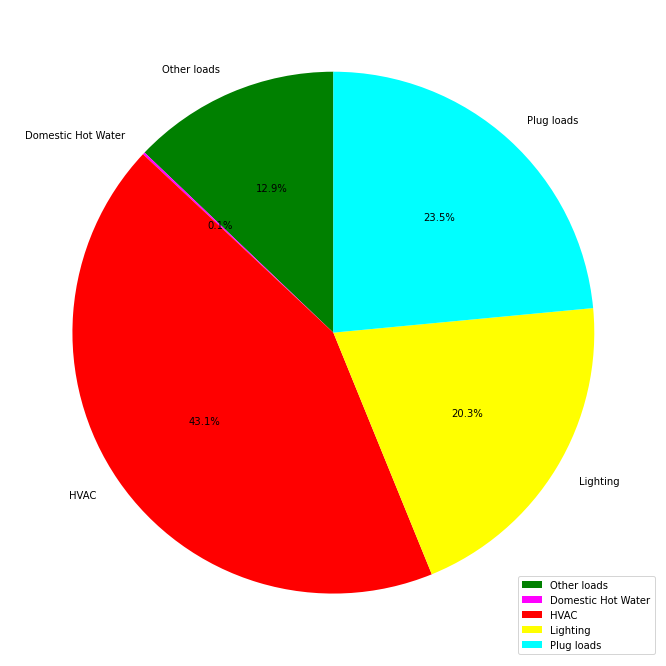

In [67]:
mylabels = ["Other loads", "Domestic Hot Water", "HVAC", "Lighting","Plug loads"]
mycolors = ["green", "magenta", "red", "yellow","cyan"]
plt.figure(figsize=(18, 12))
plt.pie(sp_prcent, labels = mylabels,colors = mycolors,autopct = '%1.1f%%', startangle = 90)
plt.legend()
plt.show() 

In [68]:
sp_prcent1=np.array([Other_loads.sum()/sumx.sum(),DHW.sum()/sumx.sum(),Heating_consumption/sumx.sum(),
                    Cooling_consumption/sumx.sum(),Lighting.sum()/sumx.sum(),Plug_loads.sum()/sumx.sum()])
sp_prcent1

array([0.12876935, 0.00139518, 0.24341838, 0.18799563, 0.20342333,
       0.23499814])

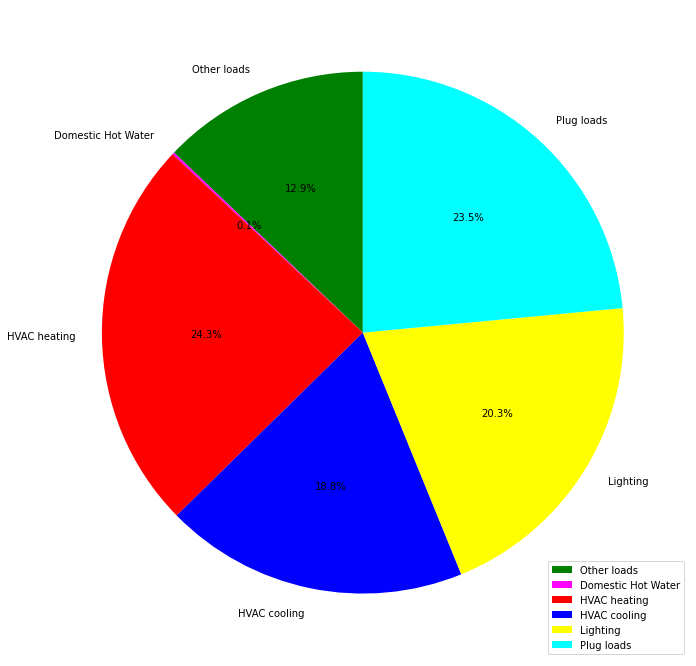

In [69]:
mylabels = ["Other loads", "Domestic Hot Water", "HVAC heating","HVAC cooling", "Lighting","Plug loads"]
mycolors = ["green", "magenta", "red","blue", "yellow","cyan"]
plt.figure(figsize=(18, 12))
plt.pie(sp_prcent1, labels = mylabels,colors = mycolors,autopct = '%1.1f%%', startangle = 90)
plt.legend(loc="lower right")
plt.show() 

In [70]:
sp_prcent_EV=np.array([Other_loads.sum()/sumx_EV.sum(),DHW.sum()/sumx_EV.sum(),HVAC.sum()/sumx_EV.sum(),
                       Lighting.sum()/sumx_EV.sum(),Plug_loads.sum()/sumx_EV.sum(),EV.sum()/sumx_EV.sum() ])
sp_prcent_EV

array([0.1252358 , 0.0013569 , 0.4195756 , 0.19784121, 0.22854957,
       0.02744094])

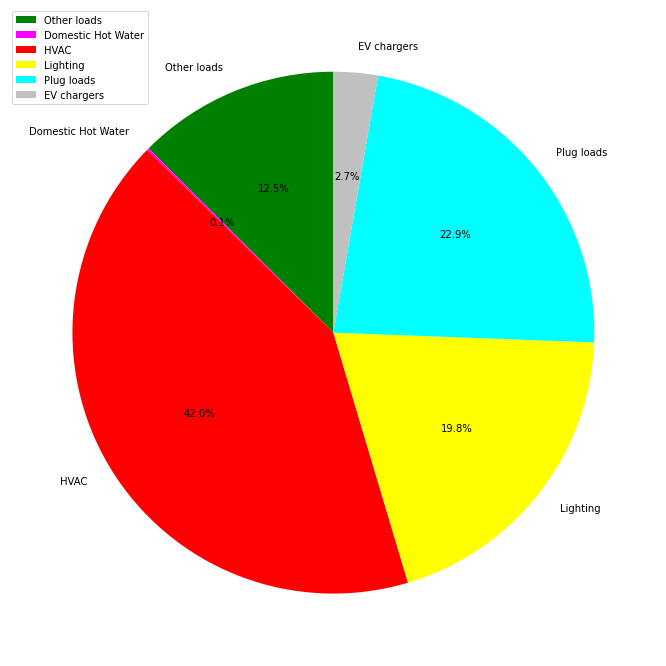

In [71]:
mylabels = ["Other loads", "Domestic Hot Water", "HVAC", "Lighting","Plug loads","EV chargers"]
mycolors = ["green", "magenta", "red", "yellow","cyan", "silver"]
plt.figure(figsize=(16, 12))
plt.pie(sp_prcent_EV, labels = mylabels,colors = mycolors,autopct = '%1.1f%%', startangle = 90)
plt.legend()
plt.show() 

In [72]:
sp_prcent_EV=np.array([Other_loads.sum()/sumx_EV.sum(),DHW.sum()/sumx_EV.sum(),Heating_consumption.sum()/sumx_EV.sum(),
                       Cooling_consumption.sum()/sumx_EV.sum(),Lighting.sum()/sumx_EV.sum(),Plug_loads.sum()/sumx_EV.sum(),EV.sum()/sumx_EV.sum() ])
sp_prcent_EV

array([0.1252358 , 0.0013569 , 0.23673875, 0.18283685, 0.19784121,
       0.22854957, 0.02744094])

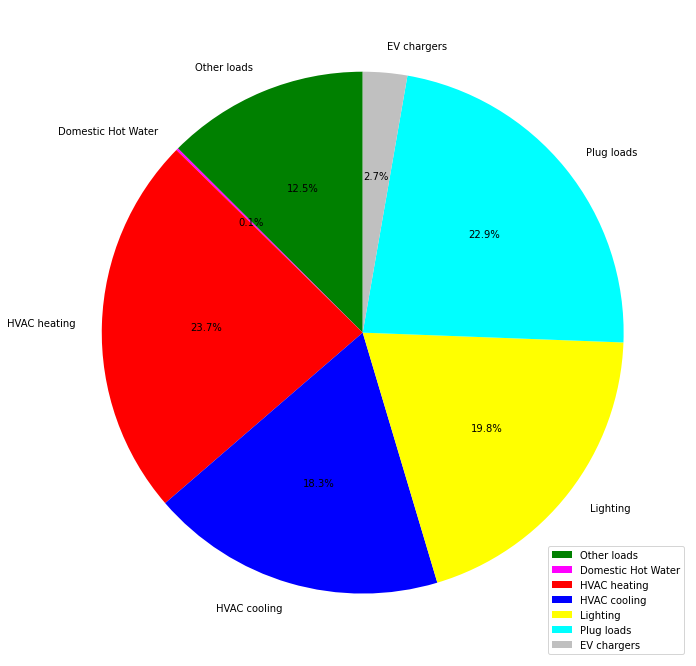

In [73]:
mylabels = ["Other loads", "Domestic Hot Water", "HVAC heating","HVAC cooling", "Lighting","Plug loads","EV chargers"]
mycolors = ["green", "magenta", "red", "blue", "yellow","cyan", "silver"]
plt.figure(figsize=(18, 12))
plt.pie(sp_prcent_EV, labels = mylabels,colors = mycolors,autopct = '%1.1f%%', startangle = 90)
plt.legend(loc="lower right")
plt.show() 

In [165]:
cl_whole_df_Lighting=pd.DataFrame(Lighting, columns=[f'Hour_{i}' for i in range(24)])
cl_N_whole_df_Lighting=pd.DataFrame(scaled_data_Lighting, columns=[f'Hour_{i}' for i in range(24)])
# consumption_cl1_df=consumption_cl1_df.reset_index(drop=True)
cl_whole_df_Lighting['Date'] = DF_[0]
cl_N_whole_df_Lighting['Date'] = DF_[0]
cl_N_whole_df_Lighting

,Hour_0,Hour_1,Hour_2,Hour_3,Hour_4,Hour_5,Hour_6,Hour_7,Hour_8,Hour_9,...,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23,Date
0,0.324147,0.322876,0.323145,0.322582,0.322802,0.322729,0.322460,0.373395,0.307666,0.285561,...,0.294877,0.316176,0.405013,0.406651,0.357012,0.323218,0.323414,0.323658,0.323585,2021-01-01
1,0.323463,0.322900,0.322925,0.322802,0.323071,0.322973,0.322020,0.350507,0.270864,0.267563,...,0.268175,0.296882,0.384521,0.384350,0.354909,0.320381,0.320430,0.321408,0.321653,2021-01-02
2,0.298032,0.320577,0.320895,0.320724,0.321017,0.320748,0.320553,0.350605,0.307177,0.338721,...,0.339063,0.366353,0.454457,0.402763,0.356816,0.326519,0.320112,0.326666,0.326641,2021-01-03
3,0.323756,0.324172,0.326666,0.326201,0.301699,0.330260,0.344150,0.449321,0.444602,0.627534,...,0.575841,0.480523,0.557134,0.446240,0.342218,0.307813,0.307837,0.307495,0.307324,2021-01-04
4,0.307837,0.307642,0.307666,0.307862,0.307250,0.307006,0.332608,0.426165,0.417973,0.505123,...,0.518401,0.540482,0.568603,0.477418,0.368285,0.322191,0.326544,0.322753,0.322069,2021-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,0.317961,0.318058,0.317985,0.317912,0.323487,0.250520,0.274508,0.278200,0.284827,0.283140,...,0.383690,0.379949,0.354664,0.319330,0.319354,0.319623,0.319379,0.319550,0.318352,2023-12-27
1091,0.318132,0.318181,0.318058,0.317912,0.324147,0.348673,0.264458,0.279496,0.285169,0.288519,...,0.437046,0.410515,0.360827,0.320210,0.318474,0.319085,0.319232,0.319672,0.319819,2023-12-28
1092,0.319648,0.319550,0.319526,0.319452,0.324490,0.340653,0.278592,0.275682,0.275462,0.275290,...,0.558748,0.542756,0.466463,0.327888,0.319134,0.319403,0.319501,0.319648,0.319795,2023-12-29
1093,0.319575,0.319599,0.319721,0.319721,0.319526,0.344834,0.266487,0.263284,0.262917,0.293679,...,0.380609,0.380144,0.355031,0.319575,0.319672,0.314953,0.318890,0.318963,0.319403,2023-12-30


In [180]:
import pandas as pd
import numpy as np

# Assume cl1_df is your DataFrame with columns 'Date', 'Hour_0' to 'Hour_23'

# Function to detect outliers using the IQR method and replace them with zeros
def replace_outliers_with_zeros(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 4 * IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Replace outliers with zero
        replaced_df[column_name] = np.where(is_outlier, 0, hour_data)

    return replaced_df

# Function to detect outliers using the IQR method and replace them with the average
def replace_outliers_with_average(data):
    replaced_df = data.copy()

    for hour in range(24):
        column_name = f'Hour_{hour}'
        hour_data = data[column_name]

        Q1 = np.percentile(hour_data, 25)
        Q3 = np.percentile(hour_data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5* IQR
        upper_bound = Q3 + 4.5* IQR

        is_outlier = (hour_data < lower_bound) | (hour_data > upper_bound)

        # Calculate the mean for each hour
        mean = np.mean(hour_data)

        # Replace outliers with the mean
        replaced_data = hour_data.copy()
        replaced_data[is_outlier] = mean
        replaced_df[column_name] = replaced_data

    return replaced_df

# Detect outliers and replace them with zeros
replaced_with_zeros_df = replace_outliers_with_zeros(cl_N_whole_df_Lighting)

# Detect outliers and replace them with average
replaced_with_average_df = replace_outliers_with_average(cl_N_whole_df_Lighting)

# Output the DataFrame with outliers replaced by zeros
print("Data with Outliers Replaced by Zeros:")
print(replaced_with_zeros_df)

# Output the DataFrame with outliers replaced by average
print("Data with Outliers Replaced by Average:")
print(replaced_with_average_df)

Data with Outliers Replaced by Zeros:
        Hour_0    Hour_1    Hour_2    Hour_3    Hour_4    Hour_5    Hour_6  \
0     0.324147  0.322876  0.323145  0.322582  0.322802  0.322729  0.322460   
1     0.323463  0.322900  0.322925  0.322802  0.323071  0.322973  0.322020   
2     0.298032  0.320577  0.320895  0.320724  0.321017  0.320748  0.320553   
3     0.323756  0.324172  0.326666  0.326201  0.301699  0.330260  0.344150   
4     0.307837  0.307642  0.307666  0.307862  0.307250  0.307006  0.332608   
...        ...       ...       ...       ...       ...       ...       ...   
1090  0.317961  0.318058  0.317985  0.317912  0.323487  0.250520  0.274508   
1091  0.318132  0.318181  0.318058  0.317912  0.324147  0.348673  0.264458   
1092  0.319648  0.319550  0.319526  0.319452  0.324490  0.340653  0.278592   
1093  0.319575  0.319599  0.319721  0.319721  0.319526  0.344834  0.266487   
1094  0.319672  0.319623  0.319844  0.319819  0.319501  0.344688  0.249248   

        Hour_7    Hour_8 

In [181]:
# Initialize a NumPy array to store the count of zeros for each day
final_replaced_df=replaced_with_zeros_df
zero_counts = np.zeros(len(replaced_with_zeros_df['Date'].unique()))

# Iterate over each unique date
for i, date in enumerate(replaced_with_zeros_df['Date'].unique()):
    # Count the number of zeros in each day
    daily_data = replaced_with_zeros_df[replaced_with_zeros_df['Date'] == date]
    zero_count = (daily_data.iloc[:, 1:] == 0).sum().sum()  # count zeros in all hours of the day
    zero_counts[i] = zero_count
    if zero_count > 4:
        # Make all the values of that day zero
        final_replaced_df.loc[final_replaced_df['Date'] == date, final_replaced_df.columns[0:]] = 0
    else:
        # Replace zeroes with the corresponding values from replaced_with_average_df for this day
        for hour in range(24):
            column_name = f'Hour_{hour}'
            final_replaced_df.loc[(final_replaced_df['Date'] == date) & (final_replaced_df[column_name] == 0), column_name] = replaced_with_average_df.loc[replaced_with_average_df['Date'] == date, column_name]

# Output the final DataFrame
print("Final DataFrame with replacements based on the number of zeroes:")
print(final_replaced_df)


Final DataFrame with replacements based on the number of zeroes:
        Hour_0    Hour_1    Hour_2    Hour_3    Hour_4    Hour_5    Hour_6  \
0     0.324147  0.322876  0.323145  0.322582  0.322802  0.322729  0.322460   
1     0.323463  0.322900  0.322925  0.322802  0.323071  0.322973  0.322020   
2     0.298032  0.320577  0.320895  0.320724  0.321017  0.320748  0.320553   
3     0.323756  0.324172  0.326666  0.326201  0.301699  0.330260  0.344150   
4     0.307837  0.307642  0.307666  0.307862  0.307250  0.307006  0.332608   
...        ...       ...       ...       ...       ...       ...       ...   
1090  0.317961  0.318058  0.317985  0.317912  0.323487  0.250520  0.274508   
1091  0.318132  0.318181  0.318058  0.317912  0.324147  0.348673  0.264458   
1092  0.319648  0.319550  0.319526  0.319452  0.324490  0.340653  0.278592   
1093  0.319575  0.319599  0.319721  0.319721  0.319526  0.344834  0.266487   
1094  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

In [182]:
cl_Lighting_clean=final_replaced_df.drop(columns=['Date']) 
cl_Lighting_clean=cl_Lighting_clean.values
Lighting_N_clean=cl_Lighting_clean

In [74]:
def calculate_ssd(x, y, a, b):
    return np.sum((y - (a * x + b))**2)

# Apply the elbow method to find a "breaking point"
def find_breaking_point(x, y):
    ssds = []
    for i in range(1, len(x)):
        a1, b1 = np.polyfit(x[:i], y[:i], 1)
        a2, b2 = np.polyfit(x[i:], y[i:], 1)
        ssd = calculate_ssd(x[:i], y[:i], a1, b1) + calculate_ssd(x[i:], y[i:], a2, b2)
        ssds.append(ssd)
            
    # Apply elbow detection logic to identify the breaking point
    diff_ssds = np.diff(ssds)
    max_diff_index = np.argmax(diff_ssds)
    
    return max_diff_index + 1

breaking point = 14


C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/3288144860.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))
C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/3288144860.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))


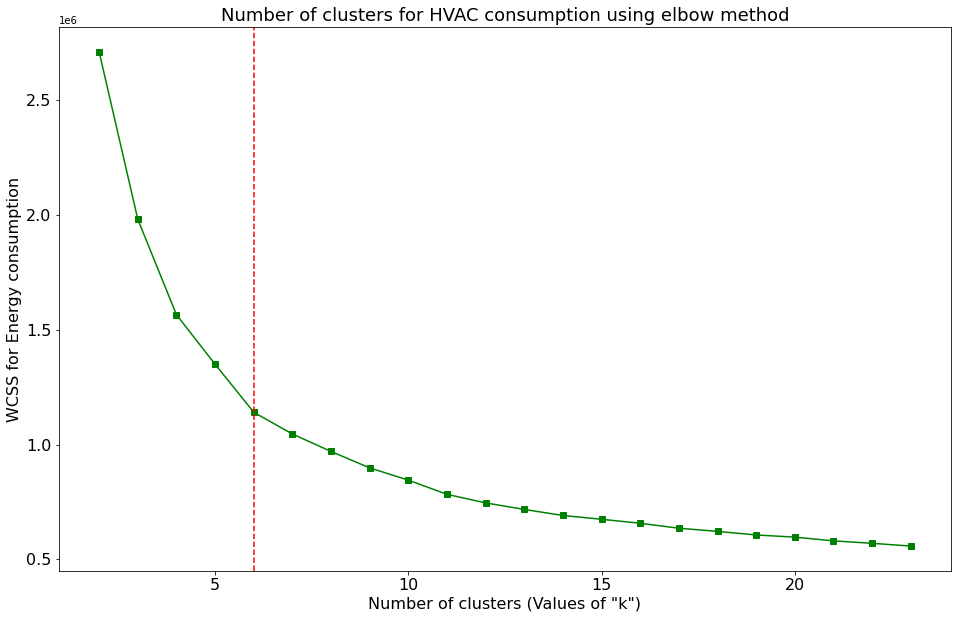

In [78]:
# determining the maximum number of clusters for HVAC consumption of Evolv1
# using the elbow method
from sklearn.cluster import KMeans
limit = int((HVAC.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(HVAC)
    wcss[k] = model.inertia_
elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
# plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
plt.axvline(x=6, color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")',fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('WCSS for Energy consumption',fontsize=16)
plt.yticks(fontsize=16)
plt.title("Number of clusters for HVAC consumption using elbow method",fontsize=18)
plt.show()

breaking point = 13


C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/3350017741.py:18: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point2=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))
C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/3350017741.py:18: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point2=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))


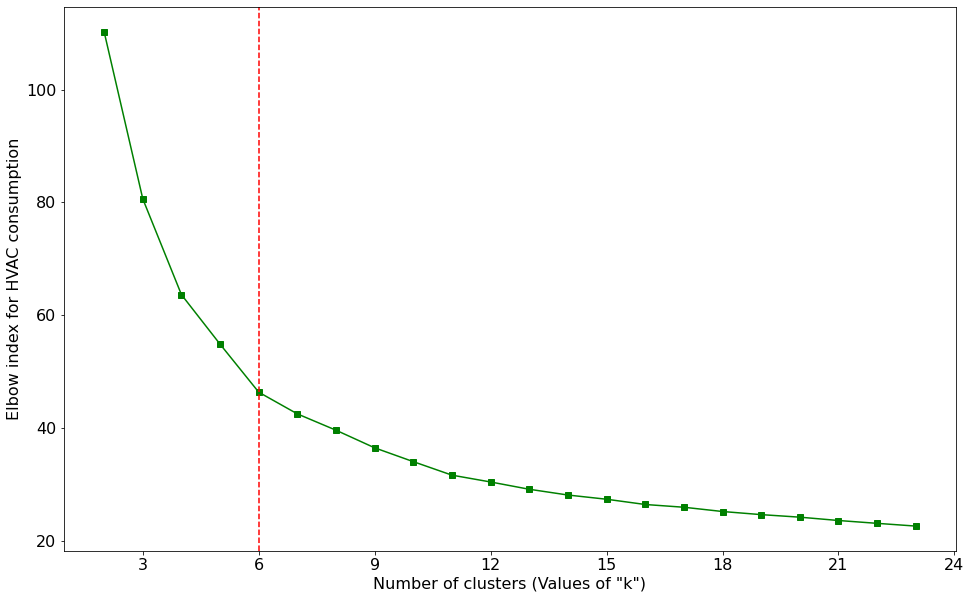

In [79]:
# determining the maximum number of clusters for HVAC consumption of Evolv1 Normalized data 
# using the elbow method
from matplotlib.ticker import MaxNLocator
from sklearn.cluster import KMeans
limit = int((scaled_data_HVAC.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(scaled_data_HVAC)
    wcss[k] = model.inertia_
elbow_break_point2=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point2}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
# plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
plt.axvline(x=6, color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")',fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('Elbow index for HVAC consumption',fontsize=16)
plt.yticks(fontsize=16)
# plt.title("Number of clusters for HVAC consumption using elbow method")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

breaking point = 7


C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/2815094520.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))
C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/2815094520.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))


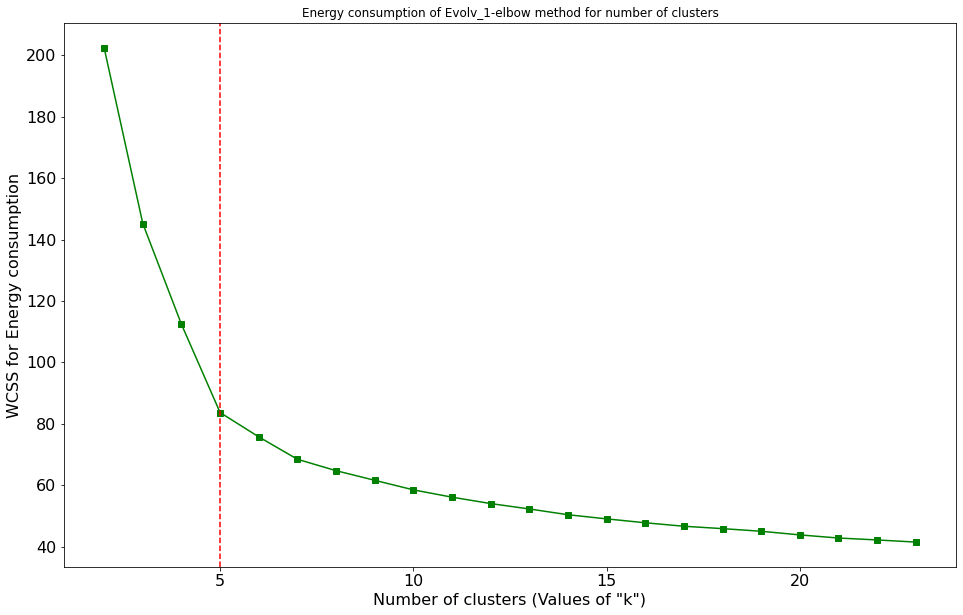

In [173]:
# determining the maximum number of clusters for Lighting consumption of Evolv1
# using the elbow method
from sklearn.cluster import KMeans
limit = int((Lighting_N_clean.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(Lighting_N_clean)
    wcss[k] = model.inertia_
elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
# plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
plt.axvline(x=5, color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")', fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('WCSS for Energy consumption', fontsize=16)
plt.yticks(fontsize=16)
plt.title("Energy consumption of Evolv_1-elbow method for number of clusters")
plt.show()

breaking point = 5


C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/1010039149.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))
C:\Users\e3akbari\AppData\Local\Temp/ipykernel_32036/1010039149.py:17: RankWarning: Polyfit may be poorly conditioned
  elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))


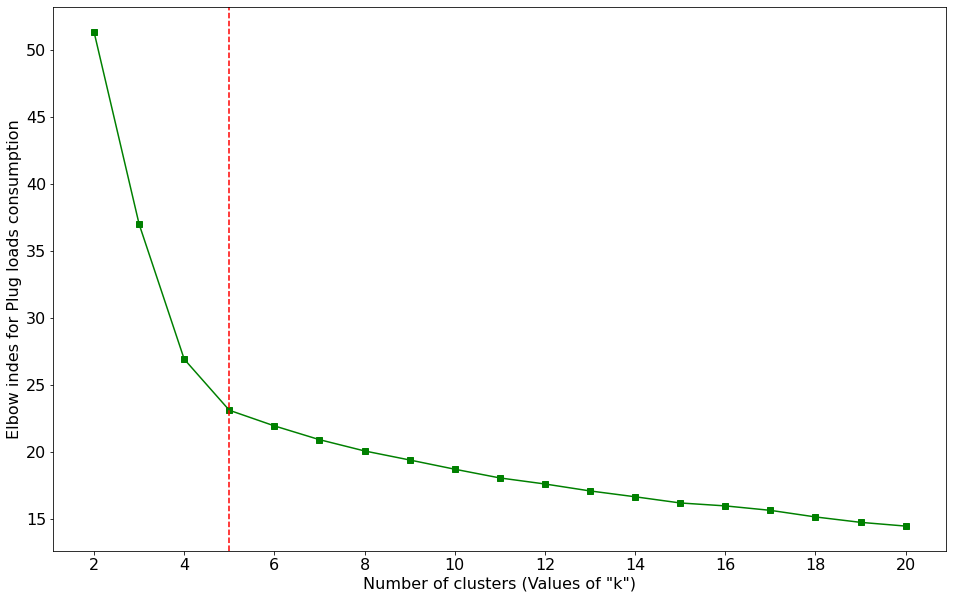

In [81]:
# determining the maximum number of clusters for Plug loads consumption of Evolv1
# using the elbow method
from sklearn.cluster import KMeans
limit = int((Plug_loads2.shape[0]//2)**0.5)
 
# selecting optimal value of 'k'
# using elbow method
 
# wcss - within cluster sum of
# squared distances
wcss = {}
 
for k in range(2,limit+1):
    model = KMeans(n_clusters=k)
    model.fit(scaled_data_Plug_loads2)
    wcss[k] = model.inertia_
elbow_break_point=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values())))     
print(f"breaking point = {elbow_break_point}")
# plotting the wcss values
# to find out the elbow value
plt.figure(figsize=(16, 10))
plt.plot(wcss.keys(), wcss.values(), 'gs-')
# plt.axvline(x=find_breaking_point(np.array(list(wcss.keys())), np.array(list(wcss.values()))), color='r', linestyle='--', label='Breaking Point')
plt.axvline(x=5, color='r', linestyle='--', label='Breaking Point')
plt.xlabel('Number of clusters (Values of "k")', fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('Elbow indes for Plug loads consumption', fontsize=16)
plt.yticks(fontsize=16)
# plt.title("Number of clusters for Plug loads consumption using elbow method")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

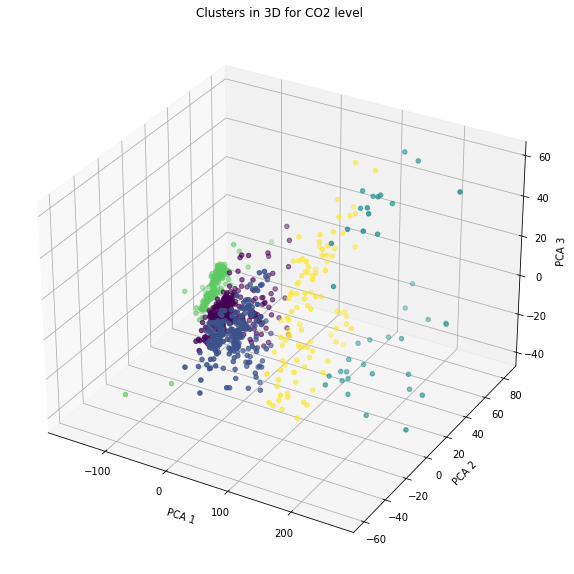

In [69]:
num_clusters = 5#elbow_break_point  # Choose an appropriate number based on the elbow plot
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(HVAC)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(HVAC)
#plt.figure(figsize=(16, 10))
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c=cluster_labels, cmap='viridis')
ax.set_title('Clusters in 3D for CO2 level')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

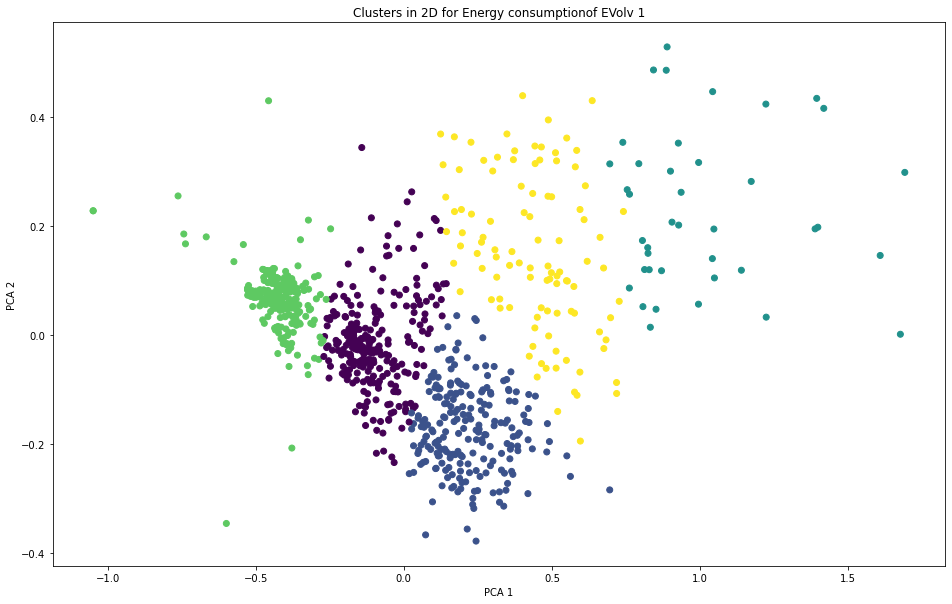

In [70]:
num_clusters = 5#elbow_break_point  # Choose an appropriate number based on the elbow plot
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data_HVAC)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data_HVAC)
#fig = plt.figure()
fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis')
ax.set_title('Clusters in 2D for Energy consumptionof EVolv 1')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
plt.show()

Silhouette Score for k = 2: 0.456
Silhouette Score for k = 3: 0.376
Silhouette Score for k = 4: 0.378
Silhouette Score for k = 5: 0.386
Silhouette Score for k = 6: 0.375
Silhouette Score for k = 7: 0.367
Silhouette Score for k = 8: 0.371
Silhouette Score for k = 9: 0.374
Silhouette Score for k = 10: 0.348
Silhouette Score for k = 11: 0.360
Silhouette Score for k = 12: 0.359
Silhouette Score for k = 13: 0.349
Silhouette Score for k = 14: 0.349
Silhouette Score for k = 15: 0.289
Silhouette Score for k = 16: 0.246
Silhouette Score for k = 17: 0.224
Silhouette Score for k = 18: 0.238
Silhouette Score for k = 19: 0.243
Silhouette Score for k = 20: 0.223
Silhouette Score for k = 21: 0.218
Silhouette Score for k = 22: 0.212
Silhouette Score for k = 23: 0.220


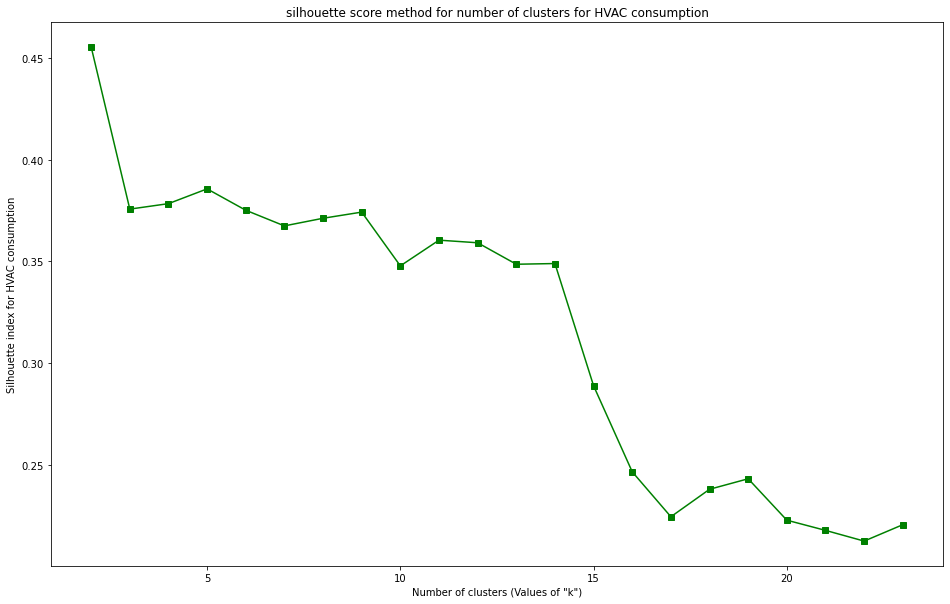

In [82]:
# determining the maximum number of clusters
# using the silhouette index for HVAC
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
limit = int((HVAC.shape[0]//2)**0.5)
 
# determining number of clusters
# using silhouette score method
Ki=np.zeros(limit-1)
silhouette_index=np.zeros(limit-1)
i=0
for k in range(2, limit+1):
    model = KMeans(n_clusters=k)
    model.fit(HVAC)
    pred = model.predict(HVAC)
    score = silhouette_score(HVAC, pred)
    Ki[i]=k
    silhouette_index[i]=score
    print('Silhouette Score for k = {}: {:<.3f}'.format(k, score))
    i=i+1

plt.figure(figsize=(16, 10))
plt.plot(Ki, silhouette_index, 'gs-')
plt.xlabel('Number of clusters (Values of "k")')
plt.ylabel('Silhouette index for HVAC consumption')
plt.title("silhouette score method for number of clusters for HVAC consumption")
plt.show()

Silhouette Score for k = 2: 0.456
Silhouette Score for k = 3: 0.376
Silhouette Score for k = 4: 0.378
Silhouette Score for k = 5: 0.386
Silhouette Score for k = 6: 0.375
Silhouette Score for k = 7: 0.367
Silhouette Score for k = 8: 0.372
Silhouette Score for k = 9: 0.380
Silhouette Score for k = 10: 0.356
Silhouette Score for k = 11: 0.356
Silhouette Score for k = 12: 0.356
Silhouette Score for k = 13: 0.350
Silhouette Score for k = 14: 0.271
Silhouette Score for k = 15: 0.301
Silhouette Score for k = 16: 0.228
Silhouette Score for k = 17: 0.220
Silhouette Score for k = 18: 0.208
Silhouette Score for k = 19: 0.214
Silhouette Score for k = 20: 0.210
Silhouette Score for k = 21: 0.211
Silhouette Score for k = 22: 0.206
Silhouette Score for k = 23: 0.218


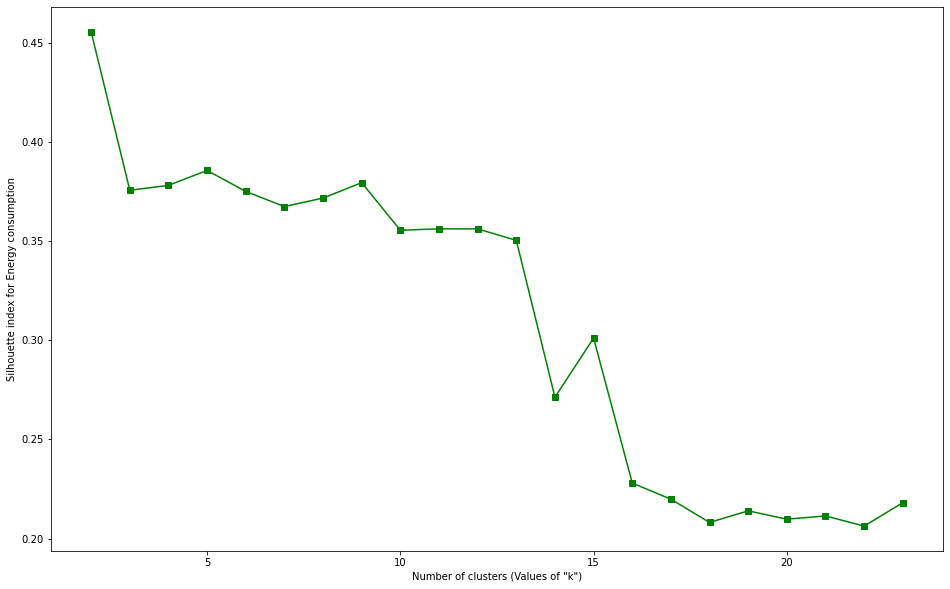

In [83]:
# determining the maximum number of clusters normalized data
# using the silhouette index for HVAC
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
limit = int((scaled_data_HVAC.shape[0]//2)**0.5)
 
# determining number of clusters
# using silhouette score method
Ki=np.zeros(limit-1)
silhouette_index=np.zeros(limit-1)
i=0
for k in range(2, limit+1):
    model = KMeans(n_clusters=k)
    model.fit(scaled_data_HVAC)
    pred = model.predict(scaled_data_HVAC)
    score = silhouette_score(scaled_data_HVAC, pred)
    Ki[i]=k
    silhouette_index[i]=score
    print('Silhouette Score for k = {}: {:<.3f}'.format(k, score))
    i=i+1

plt.figure(figsize=(16, 10))
plt.plot(Ki, silhouette_index, 'gs-')
plt.xlabel('Number of clusters (Values of "k")')
plt.ylabel('Silhouette index for Energy consumption')
# plt.title("silhouette score method for number of clusters with Normalized data for Evolv_1")
plt.show()

In [193]:
#clustering for Occ_consumption
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(scaled_Occ_consumption)

Occ_consumption_labels=kmeans.labels_

Occ_consumption_labels

array([1, 1, 1, ..., 1, 1, 3])

In [102]:
#clustering for HVAC
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0).fit(scaled_data_HVAC)

Dayly_HVAC_labels1=kmeans.labels_

Dayly_HVAC_labels1

array([5, 2, 2, ..., 0, 2, 2])

In [103]:
#clustering for Lighting 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=0).fit(scaled_data_Lighting)

Dayly_Lighting_labels1=kmeans.labels_

Dayly_Lighting_labels1

array([2, 2, 2, ..., 2, 2, 2])

In [183]:
#clustering for clean normalized Lighting 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(Lighting_N_clean)

Dayly_Lighting_labels=kmeans.labels_

Dayly_Lighting_labels

array([0, 0, 0, ..., 0, 0, 4])

In [104]:
#clustering for Plug loads 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0).fit(scaled_data_Plug_loads)

Dayly_Plug_loads_labels1=kmeans.labels_

Dayly_Plug_loads_labels1

array([4, 4, 4, ..., 4, 4, 4])

In [123]:
#clustering for Plug loads 2
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0).fit(scaled_data_Plug_loads)

Dayly_Plug_loads_labels2=kmeans.labels_

Dayly_Plug_loads_labels2

array([0, 0, 0, ..., 0, 0, 0])

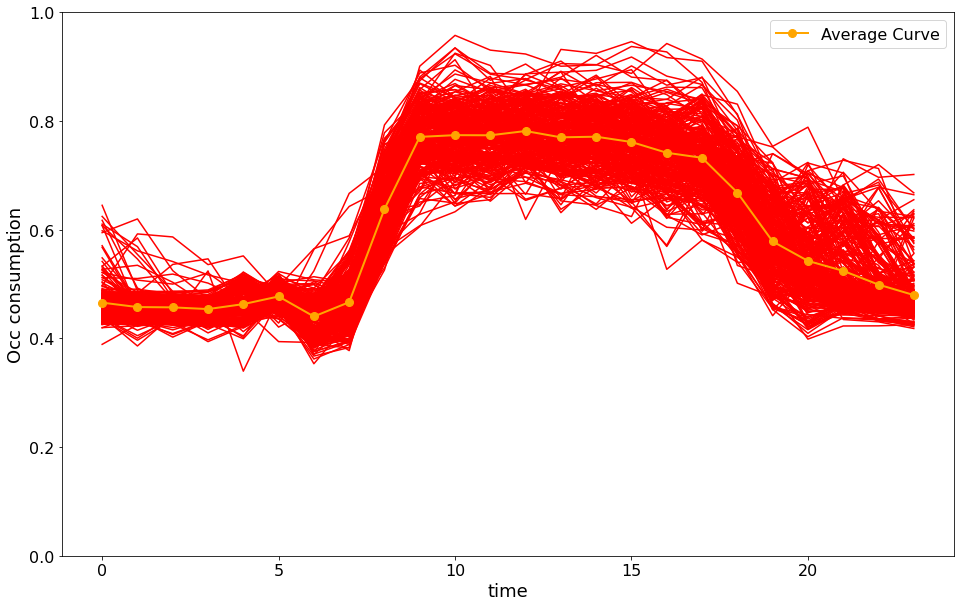

<Figure size 432x288 with 0 Axes>

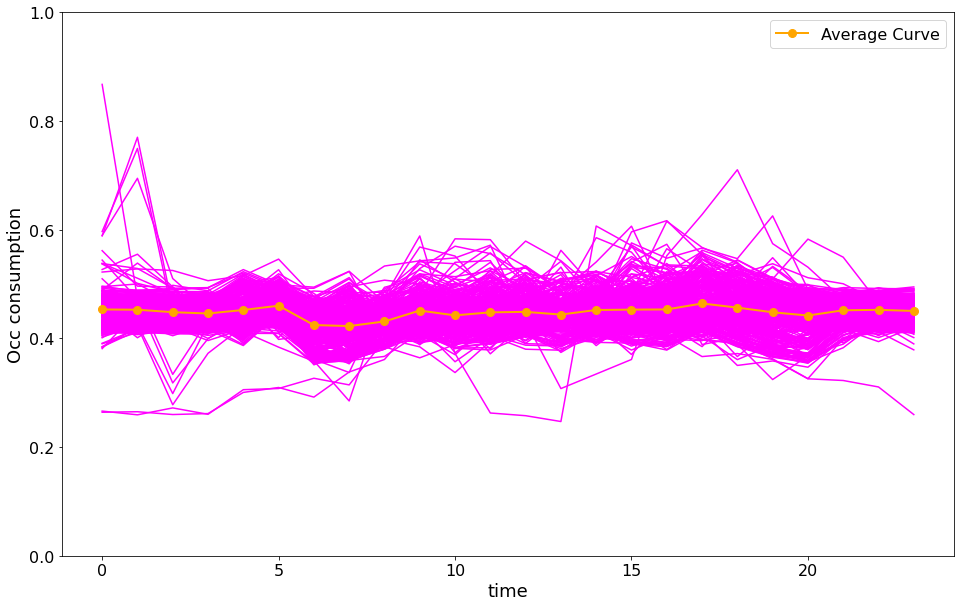

<Figure size 432x288 with 0 Axes>

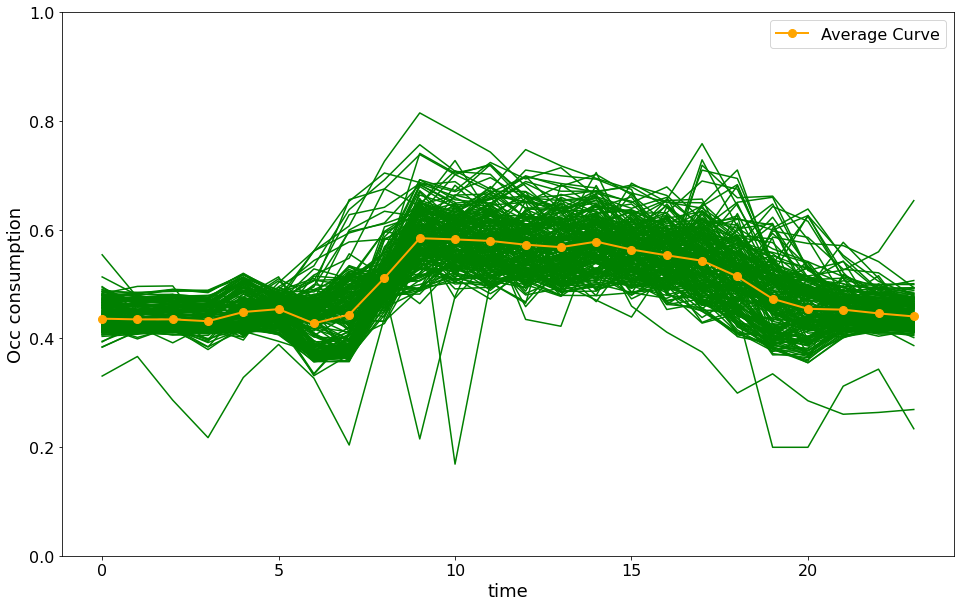

<Figure size 432x288 with 0 Axes>

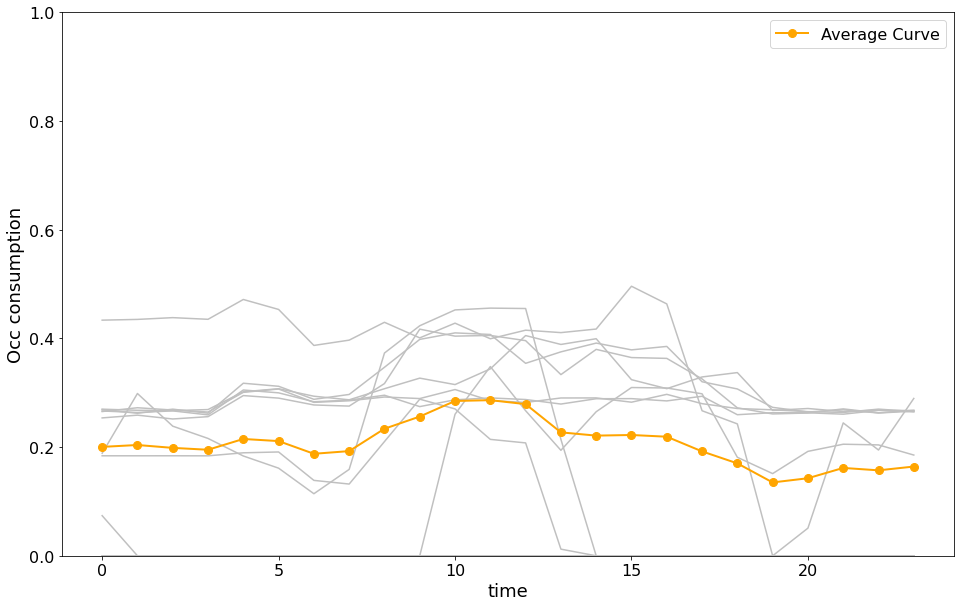

<Figure size 432x288 with 0 Axes>

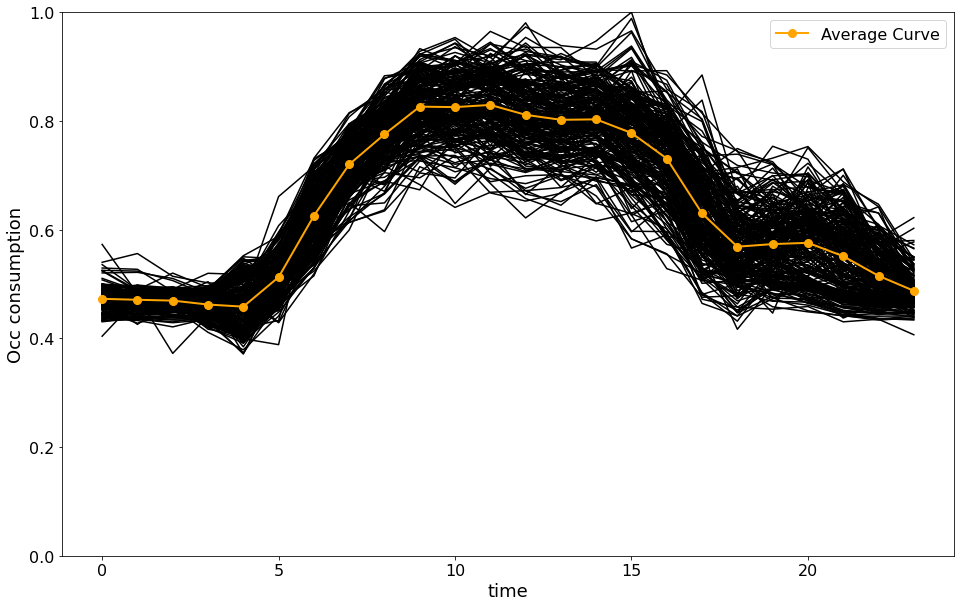

In [195]:
#Occ consumption clusters ['red','magenta','green','silver','balck']
plt.figure(figsize=(16, 10))
for i in range(Occ_consumption_labels.shape[0]):
    if Occ_consumption_labels[i]==0: 
        plt.plot(scaled_Occ_consumption[i], color = 'red') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Occ consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Occ-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Occ_consumption_labels.shape[0]):
    if Occ_consumption_labels[i]==1: 
        plt.plot(scaled_Occ_consumption[i], color = 'magenta') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 1], axis=0)   # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Occ consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("Occ-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Occ_consumption_labels.shape[0]):
    if Occ_consumption_labels[i]==2: 
        plt.plot(scaled_Occ_consumption[i], color = 'green') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 2], axis=0)   # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Occ consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Occ-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Occ_consumption_labels.shape[0]):
    if Occ_consumption_labels[i]==3: 
        plt.plot(scaled_Occ_consumption[i], color = 'silver') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 3], axis=0)   # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Occ consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Occ-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Occ_consumption_labels.shape[0]):
    if Occ_consumption_labels[i]==4: 
        plt.plot(scaled_Occ_consumption[i], color = 'black') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 4], axis=0)   # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Occ consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Occ-Cluster 5")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Occ_consumption_labels.shape[0]):
#     if Occ_consumption_labels[i]==5: 
#         plt.plot(scaled_Occ_consumption[i], color = 'green') 
#         plt.ylim(0, 1)
# average_curve = np.mean(scaled_Occ_consumption[Occ_consumption_labels == 5], axis=0)   # Calculate mean only for relevant curves
# plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# # plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
# plt.xlabel("time",fontsize=18)
# plt.xticks(fontsize=16)
# plt.ylabel("Occ consumption",fontsize=18)
# plt.yticks(fontsize=16)
# # Optional: Add a legend
# plt.legend(fontsize=16)
# # Show the plot
# plt.show()
# # plt.title("Occ-Cluster 6")

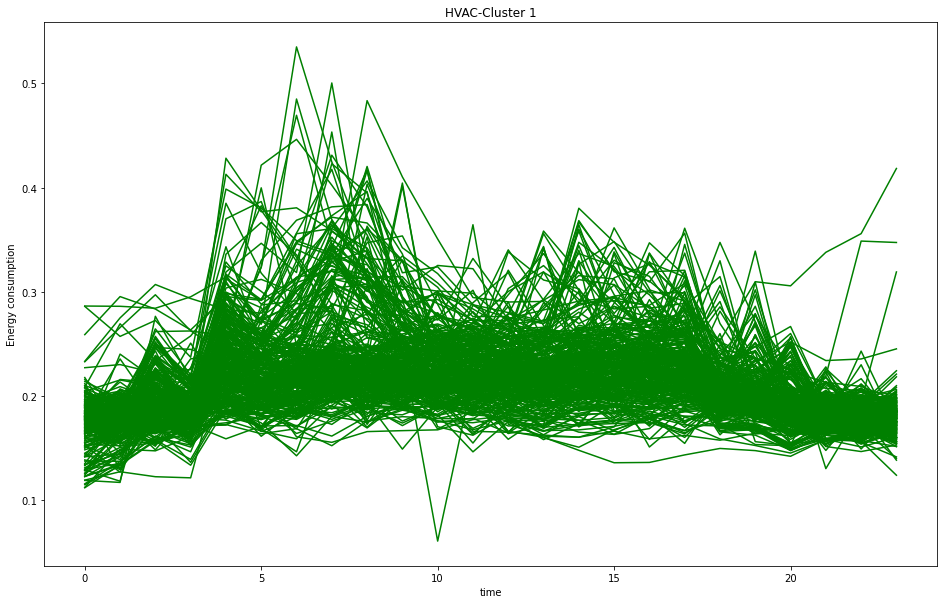

<Figure size 432x288 with 0 Axes>

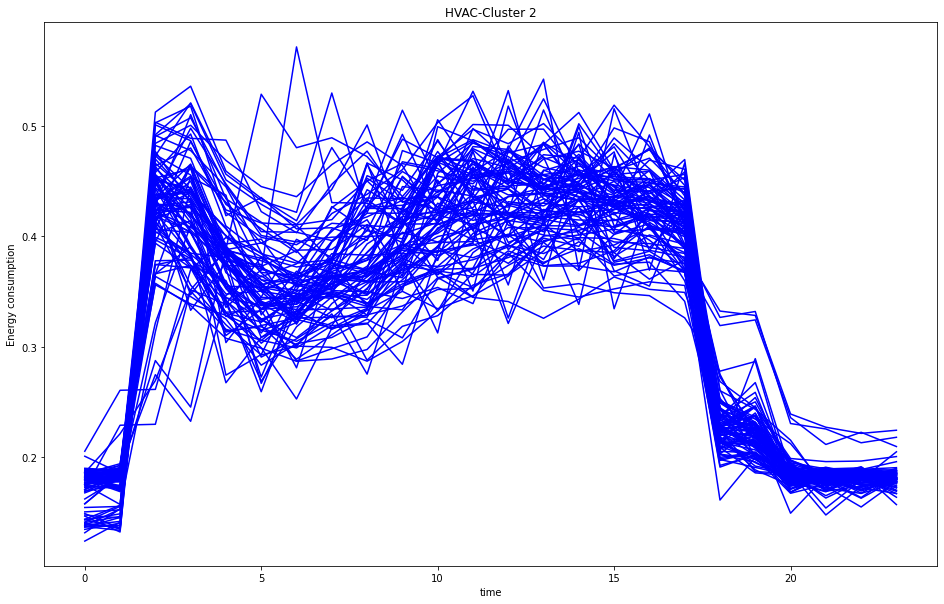

<Figure size 432x288 with 0 Axes>

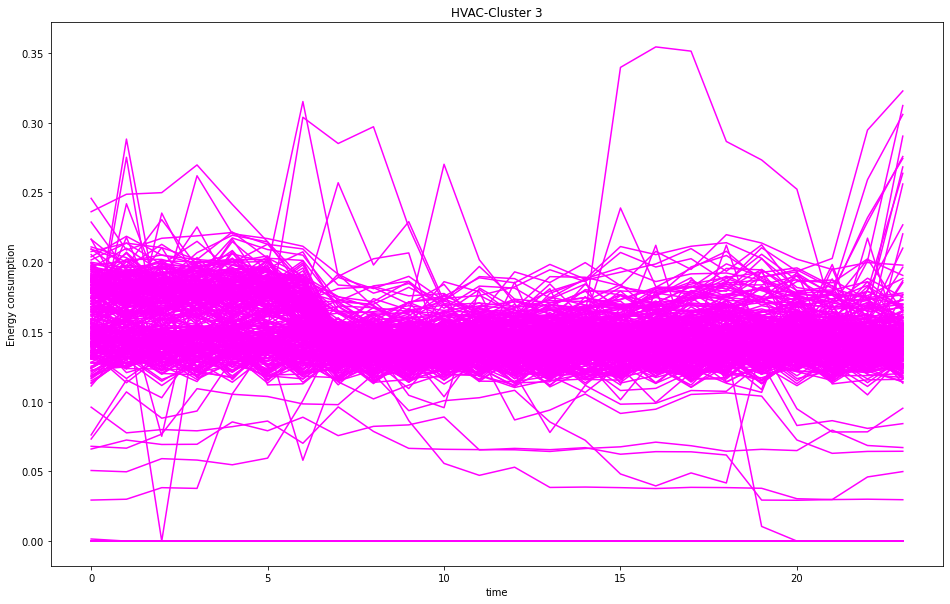

<Figure size 432x288 with 0 Axes>

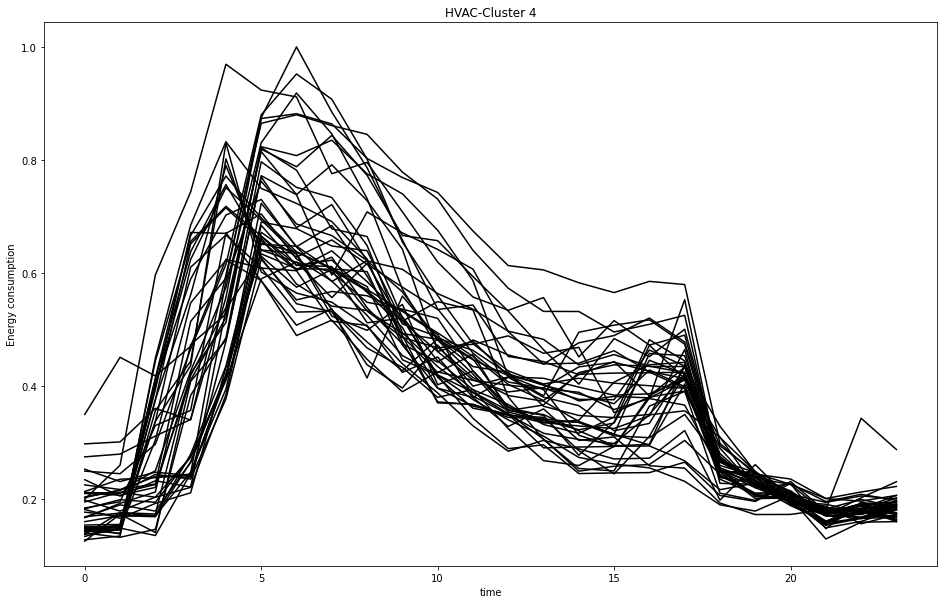

<Figure size 432x288 with 0 Axes>

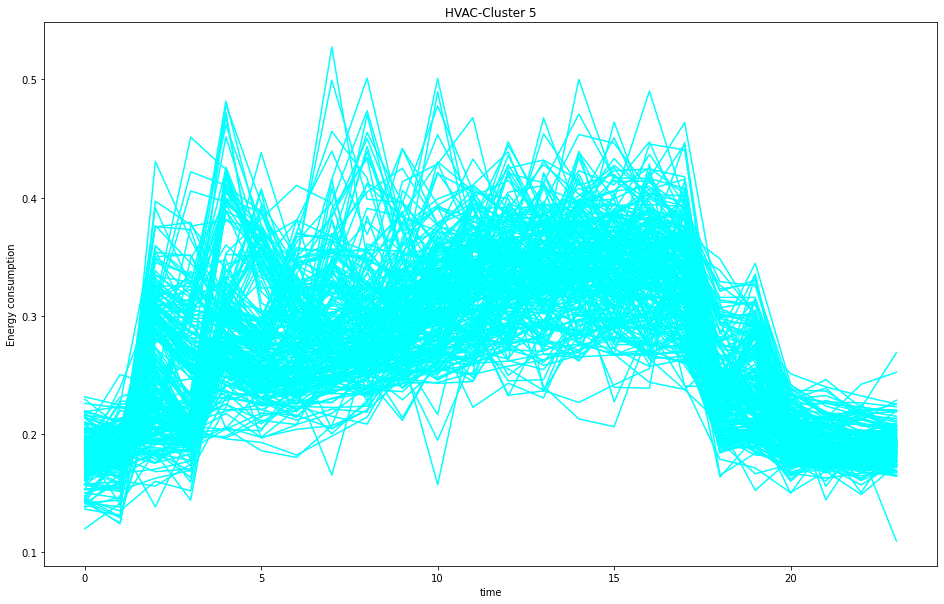

<Figure size 432x288 with 0 Axes>

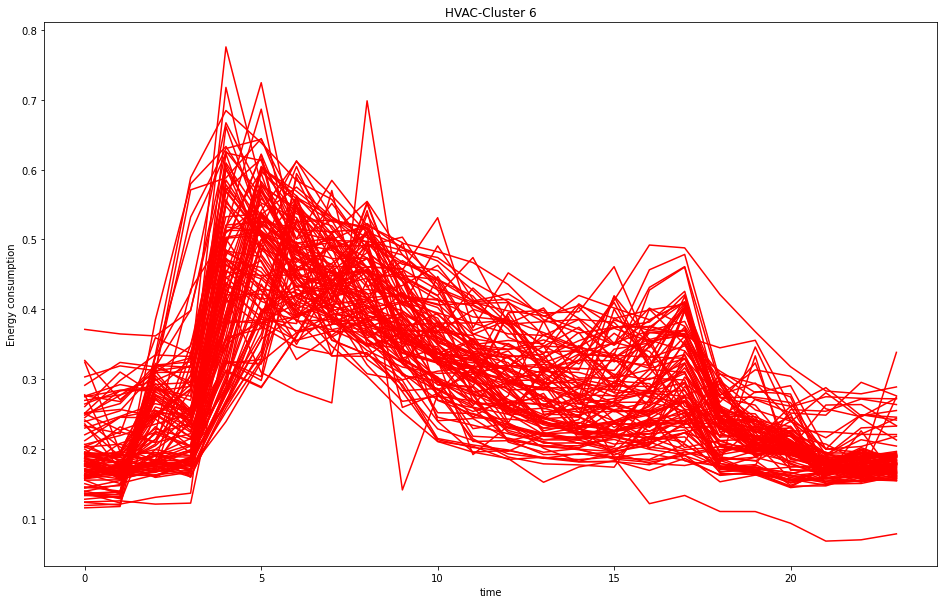

In [107]:
#HVAC clusters ['green','black','cyan','red','magenta']
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]):
    if Dayly_HVAC_labels1[i]==0: 
        plt.plot(scaled_data_HVAC[i], color = 'green') 
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("HVAC-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==1: 
        plt.plot(scaled_data_HVAC[i], color = 'blue') 
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("HVAC-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==2: 
        plt.plot(scaled_data_HVAC[i], color = 'magenta')  
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("HVAC-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==3: 
        plt.plot(scaled_data_HVAC[i], color = 'black')  
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("HVAC-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==4: 
        plt.plot(scaled_data_HVAC[i], color = 'cyan')  
        plt.xlabel("time") 
        plt.ylabel("Energy consumption")   
        plt.title("HVAC-Cluster 5")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
   if Dayly_HVAC_labels1[i]==5: 
       plt.plot(scaled_data_HVAC[i], color = 'red')  
       plt.xlabel("time") 
       plt.ylabel("Energy consumption")   
       plt.title("HVAC-Cluster 6")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==6: 
#        plt.plot(scaled_data_X_E1[i], color = 'yellow')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 7")

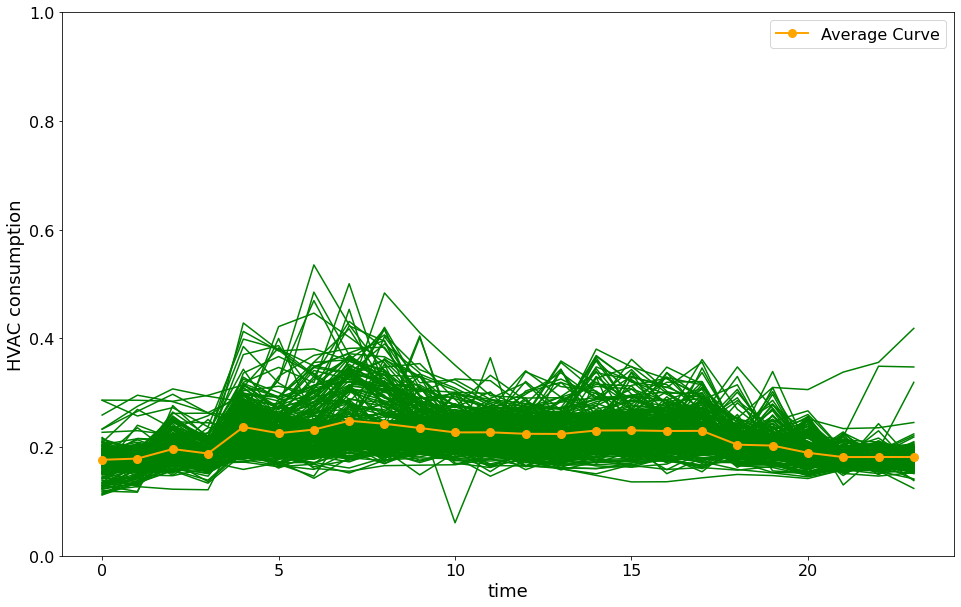

<Figure size 432x288 with 0 Axes>

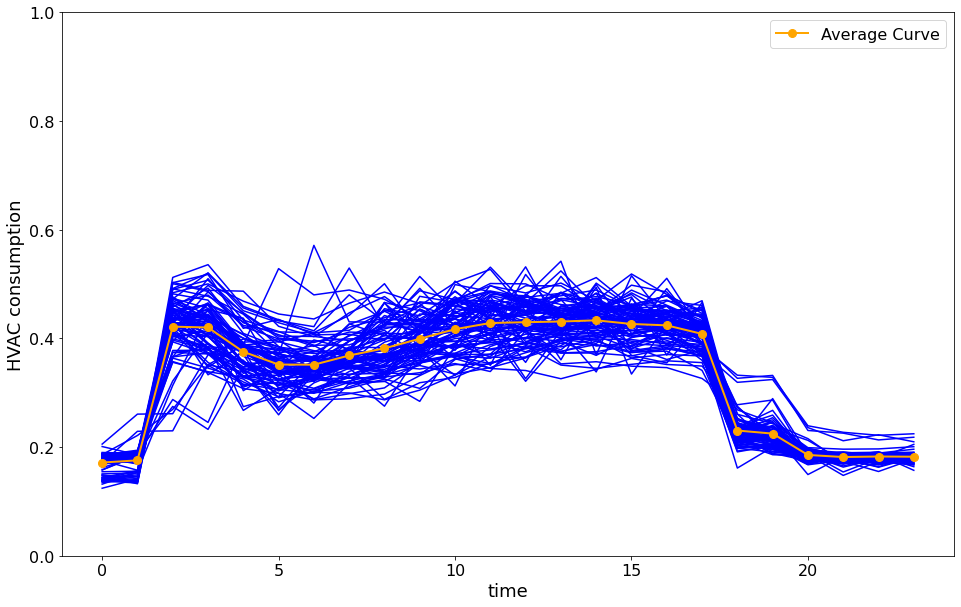

<Figure size 432x288 with 0 Axes>

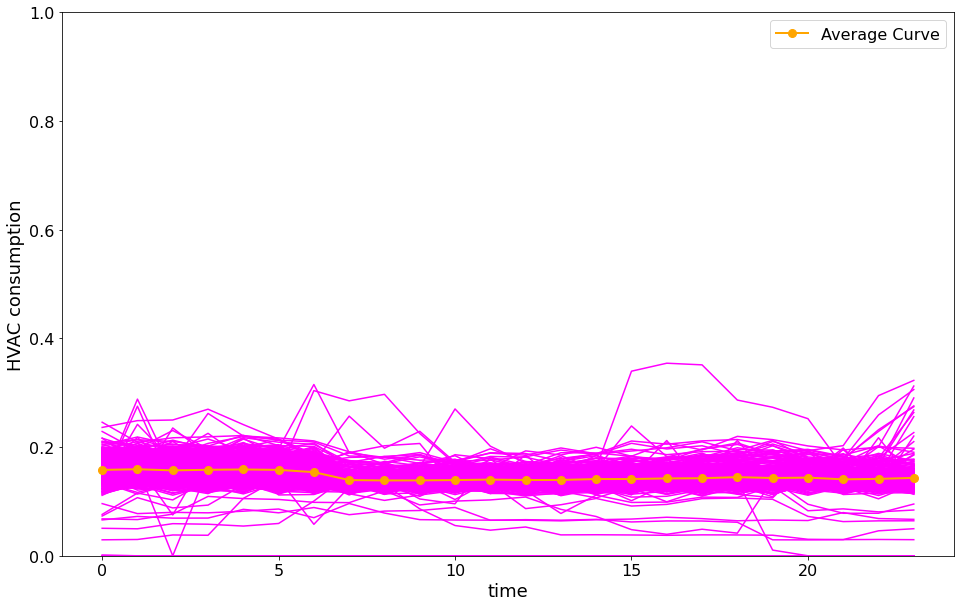

<Figure size 432x288 with 0 Axes>

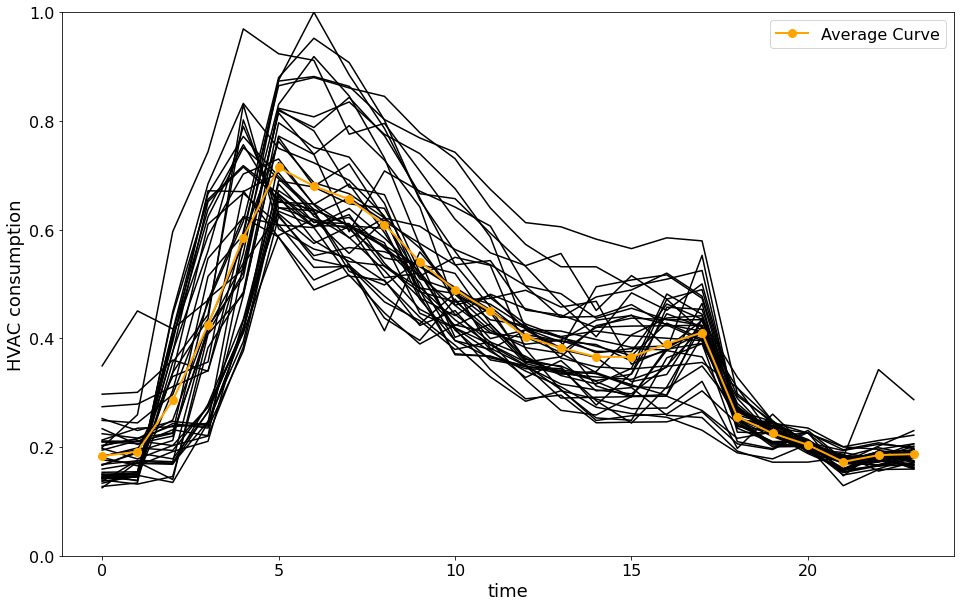

<Figure size 432x288 with 0 Axes>

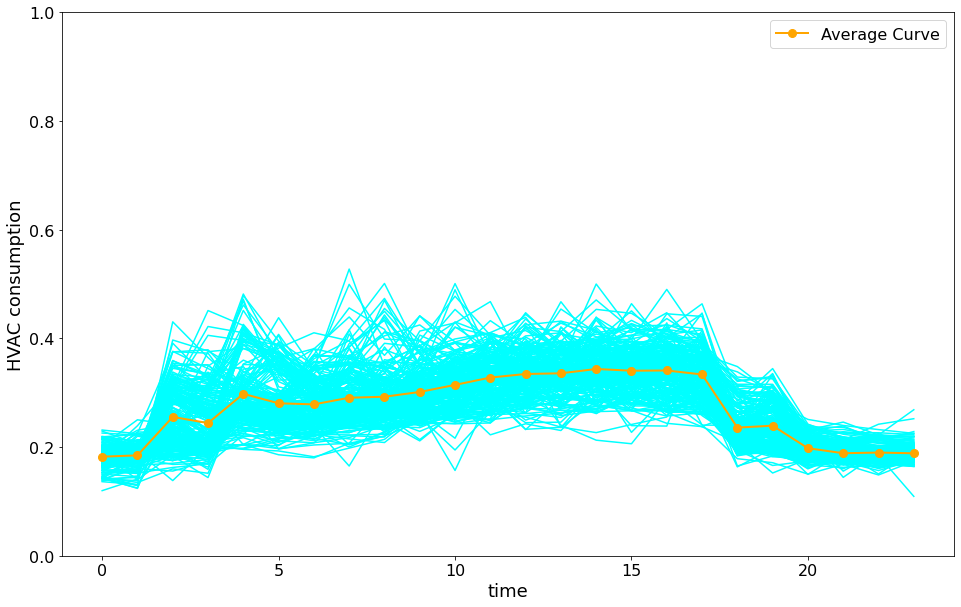

<Figure size 432x288 with 0 Axes>

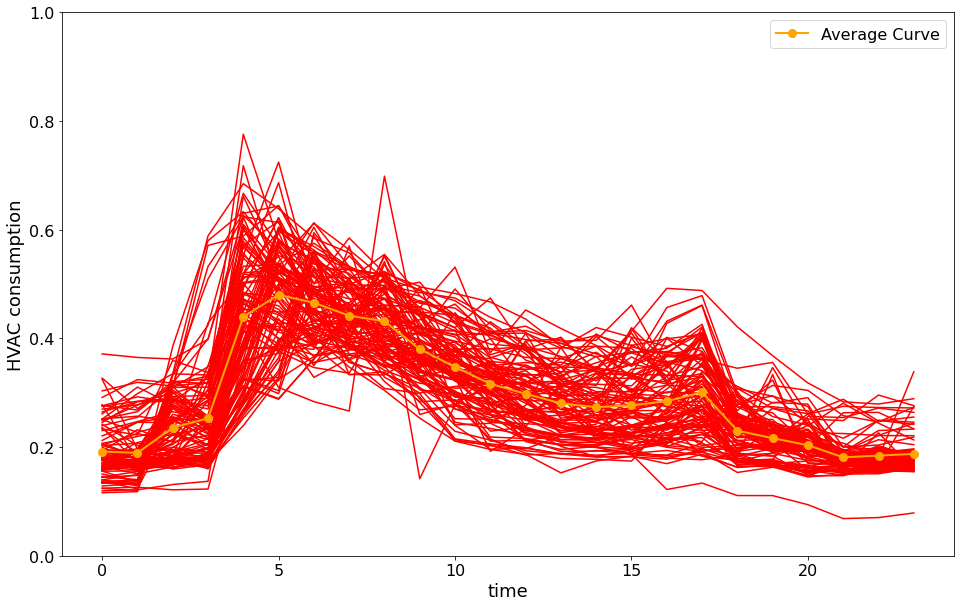

In [108]:
#HVAC clusters ['green','blue','magenta','black','cyan','red']
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]):
    if Dayly_HVAC_labels1[i]==0: 
        plt.plot(scaled_data_HVAC[i], color = 'green') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("HVAC-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==1: 
        plt.plot(scaled_data_HVAC[i], color = 'blue') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show() 
# plt.title("HVAC-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==2: 
        plt.plot(scaled_data_HVAC[i], color = 'magenta')
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("HVAC-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==3: 
        plt.plot(scaled_data_HVAC[i], color = 'black')  
plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("HVAC-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==4: 
        plt.plot(scaled_data_HVAC[i], color = 'cyan')  
plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("HVAC-Cluster 5")

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_HVAC_labels1.shape[0]): 
    if Dayly_HVAC_labels1[i]==5: 
        plt.plot(scaled_data_HVAC[i], color = 'red')  
plt.ylim(0, 1)
average_curve = np.mean(scaled_data_HVAC[Dayly_HVAC_labels1 == 5], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("HVAC consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("HVAC-Cluster 6")

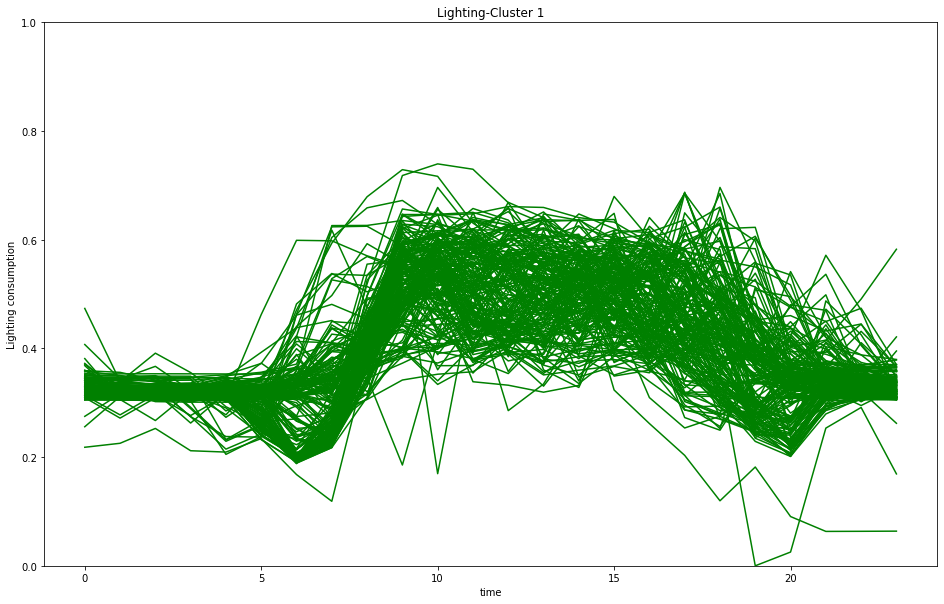

<Figure size 432x288 with 0 Axes>

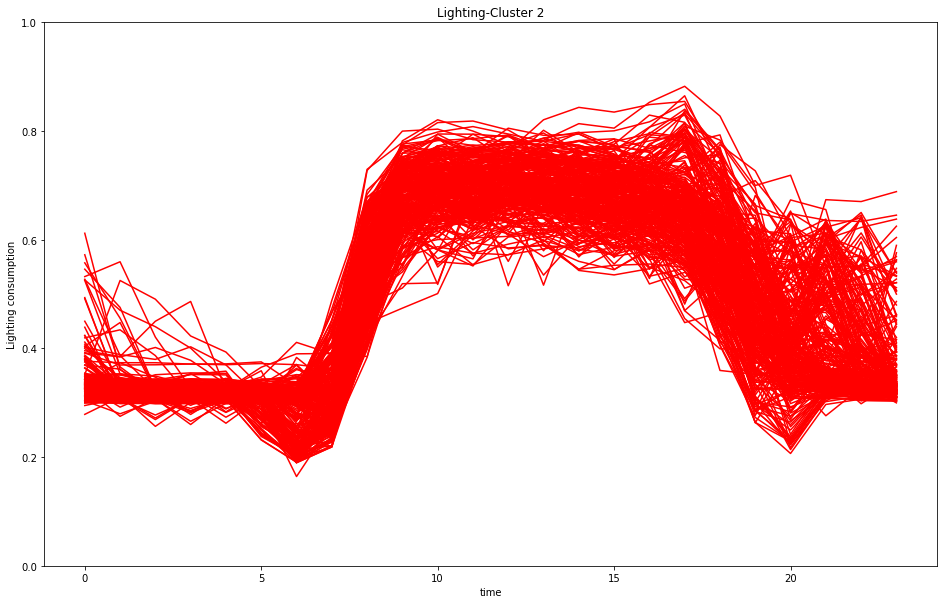

<Figure size 432x288 with 0 Axes>

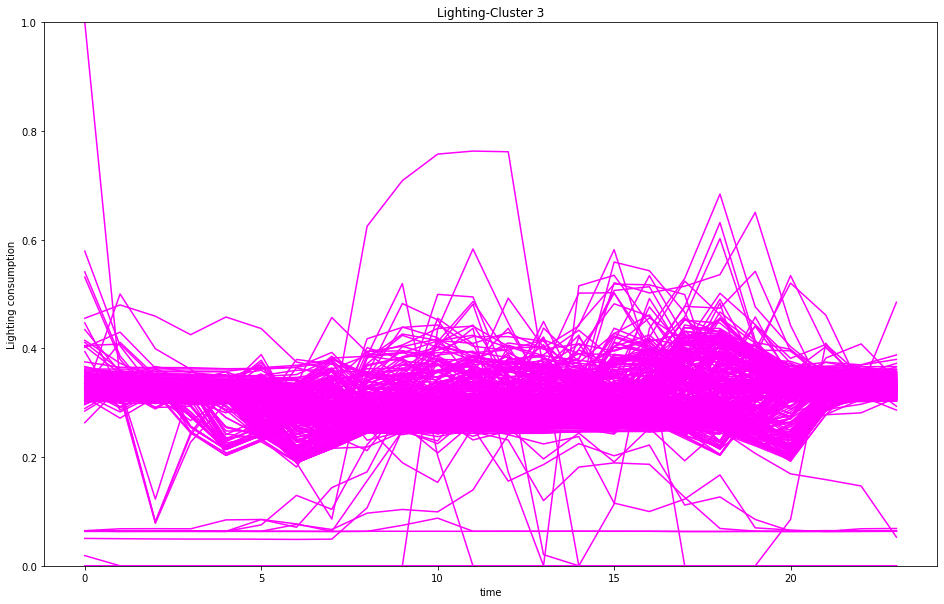

<Figure size 432x288 with 0 Axes>

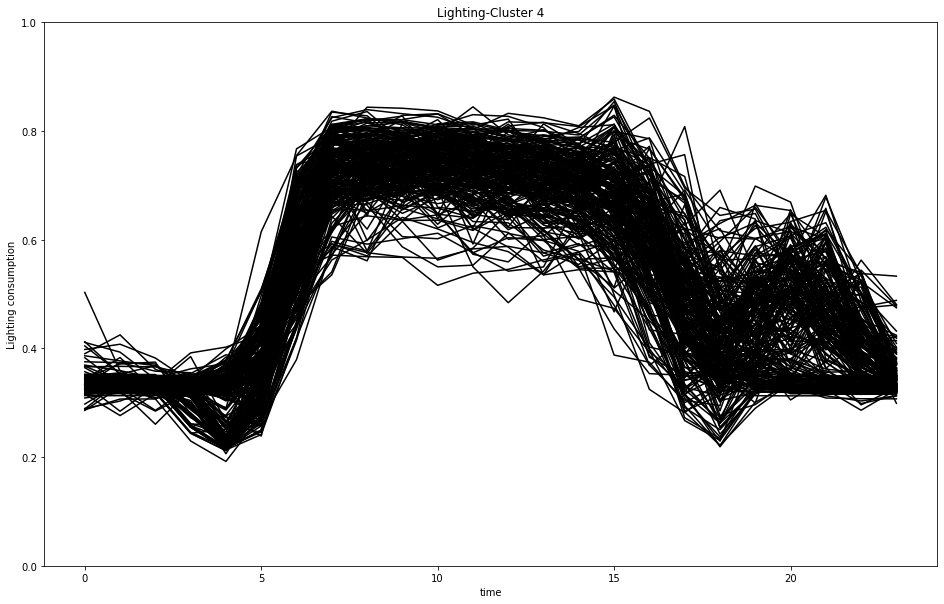

In [158]:
#with divided data for Lighting ['green','red','magenta','black']

plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels1.shape[0]):
    if Dayly_Lighting_labels1[i]==0: 
        plt.plot(scaled_data_Lighting[i], color = 'green')
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Lighting consumption")   
        plt.title("Lighting-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels1.shape[0]): 
    if Dayly_Lighting_labels1[i]==1: 
        plt.plot(scaled_data_Lighting[i], color = 'red') 
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Lighting consumption")   
        plt.title("Lighting-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels1.shape[0]): 
    if Dayly_Lighting_labels1[i]==2: 
        plt.plot(scaled_data_Lighting[i], color = 'magenta')
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Lighting consumption")   
        plt.title("Lighting-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels1.shape[0]): 
    if Dayly_Lighting_labels1[i]==3: 
        plt.plot(scaled_data_Lighting[i], color = 'black')
        plt.ylim(0, 1)
        plt.xlabel("time") 
        plt.ylabel("Lighting consumption")   
        plt.title("Lighting-Cluster 4")
        
# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(scaled_data_sumx.shape[0]): 
#     if Dayly_Energy_labels1[i]==4: 
#         plt.plot(scaled_data_X_E1[i], color = 'gray')  
#         plt.xlabel("time") 
#         plt.ylabel("Energy consumption")   
#         plt.title("Energy-Cluster 5")
        
# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==5: 
#        plt.plot(scaled_data_sumx[i], color = 'red')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 6")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==6: 
#        plt.plot(scaled_data_sumx[i], color = 'yellow')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 7")

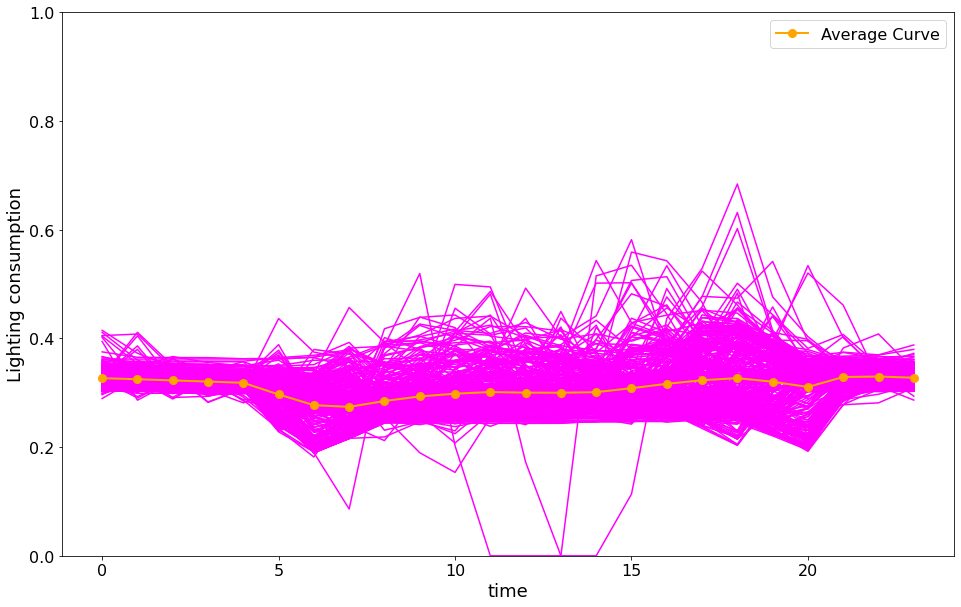

<Figure size 432x288 with 0 Axes>

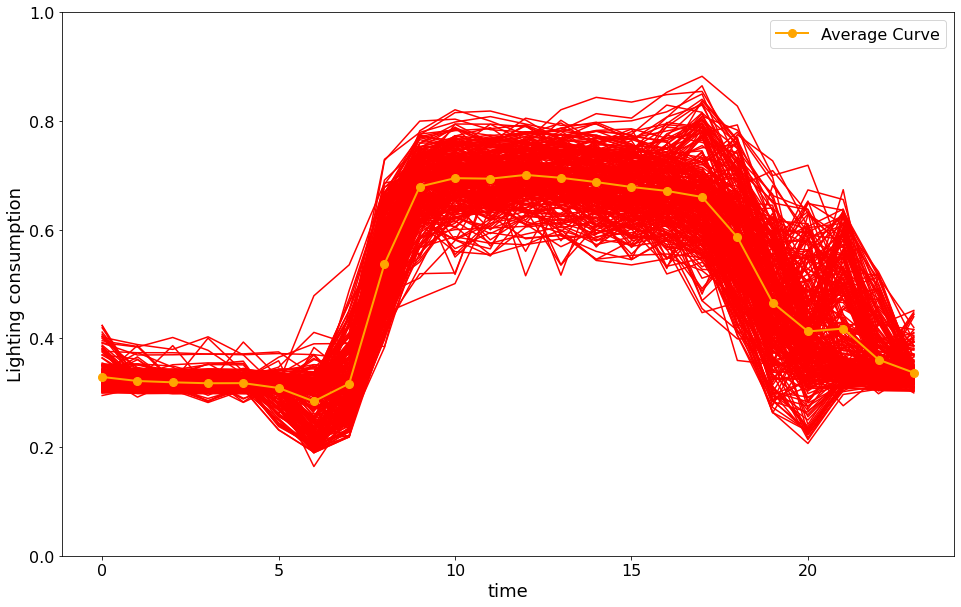

<Figure size 432x288 with 0 Axes>

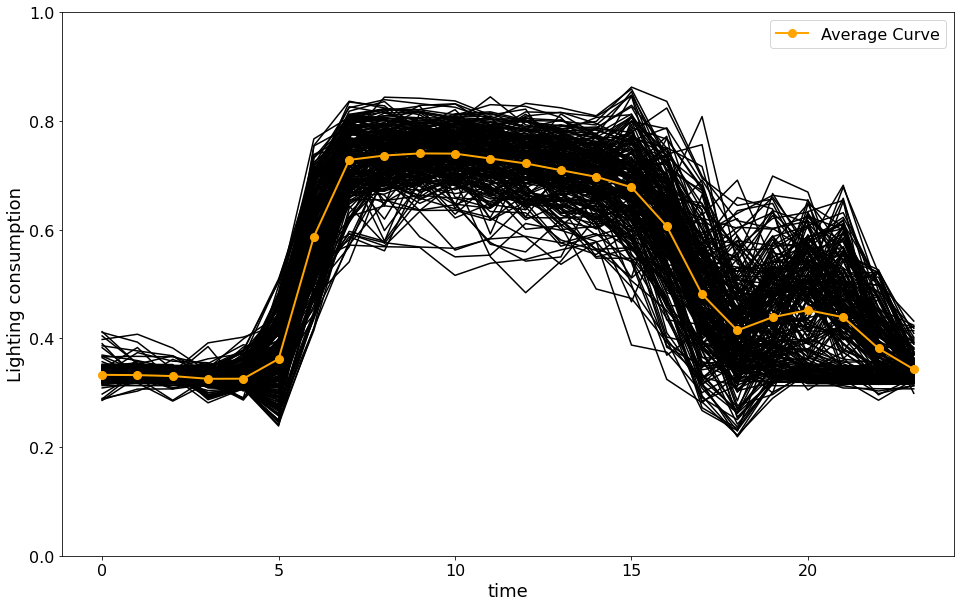

<Figure size 432x288 with 0 Axes>

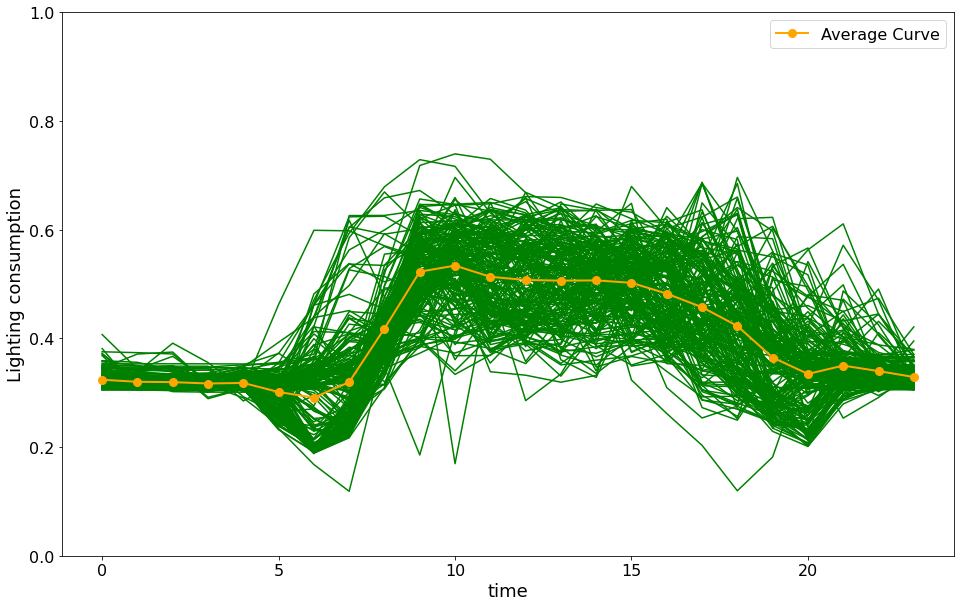

<Figure size 432x288 with 0 Axes>

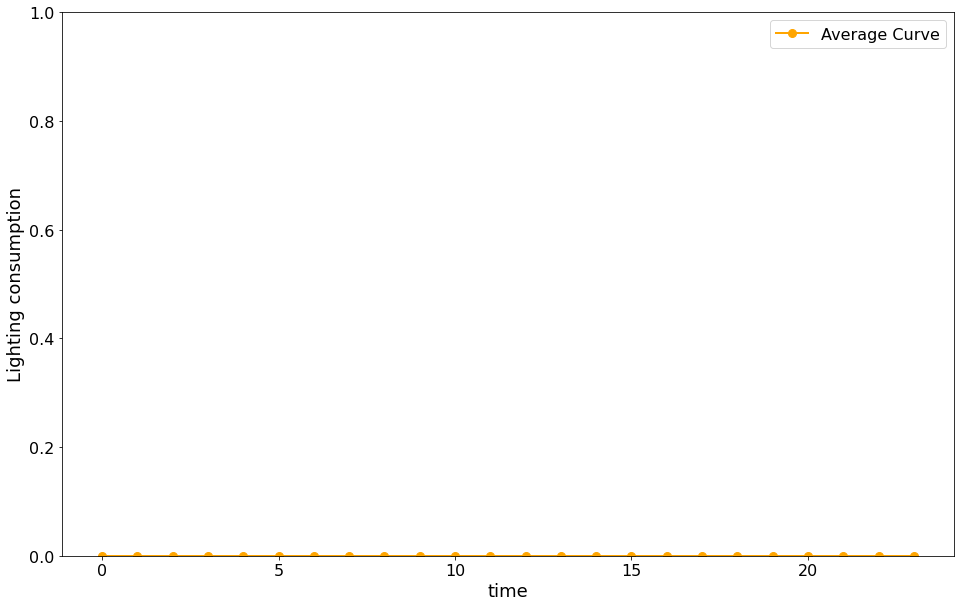

In [186]:
#with divided data for clean normalized lighting

plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels.shape[0]):
    if Dayly_Lighting_labels[i]==0: 
        plt.plot(Lighting_N_clean[i], color = 'magenta')
        plt.ylim(0, 1)
average_curve = np.mean(Lighting_N_clean[Dayly_Lighting_labels == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Lighting consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()


plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels.shape[0]): 
    if Dayly_Lighting_labels[i]==1: 
        plt.plot(Lighting_N_clean[i], color = 'red') 
        plt.ylim(0, 1)
average_curve = np.mean(Lighting_N_clean[Dayly_Lighting_labels == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Lighting consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels.shape[0]): 
    if Dayly_Lighting_labels[i]==2: 
        plt.plot(Lighting_N_clean[i], color = 'black')
        plt.ylim(0, 1)
average_curve = np.mean(Lighting_N_clean[Dayly_Lighting_labels == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Lighting consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels.shape[0]): 
    if Dayly_Lighting_labels[i]==3: 
        plt.plot(Lighting_N_clean[i], color = 'green')
        plt.ylim(0, 1)
average_curve = np.mean(Lighting_N_clean[Dayly_Lighting_labels == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Lighting consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Lighting_labels.shape[0]): 
    if Dayly_Lighting_labels[i]==4: 
        plt.plot(Lighting_N_clean[i], color = 'gray')
        plt.ylim(0, 1)
average_curve = np.mean(Lighting_N_clean[Dayly_Lighting_labels == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='orange', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Lighting consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
        
# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==5: 
#        plt.plot(scaled_data_sumx[i], color = 'red')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 6")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==6: 
#        plt.plot(scaled_data_sumx[i], color = 'yellow')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 7")

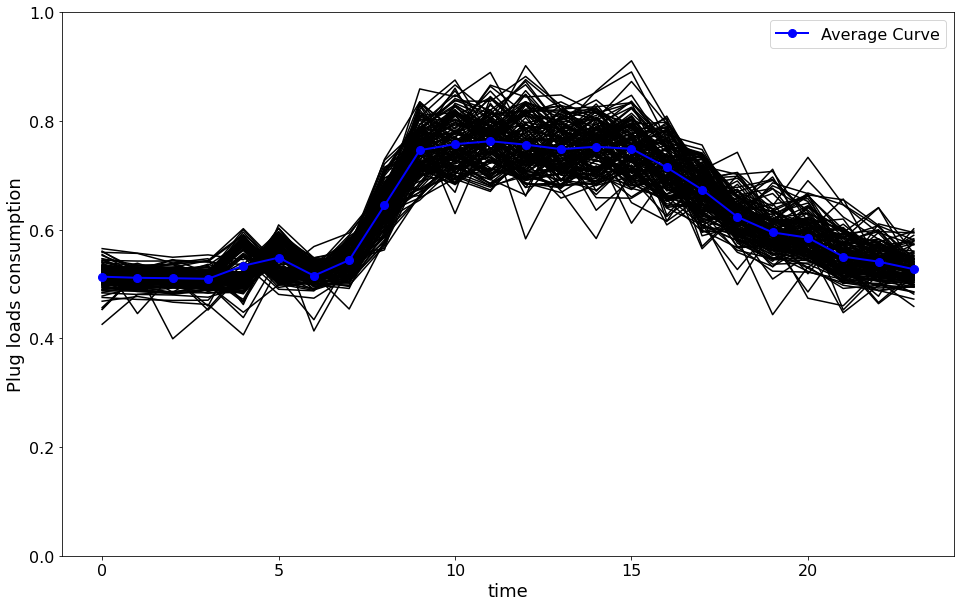

<Figure size 432x288 with 0 Axes>

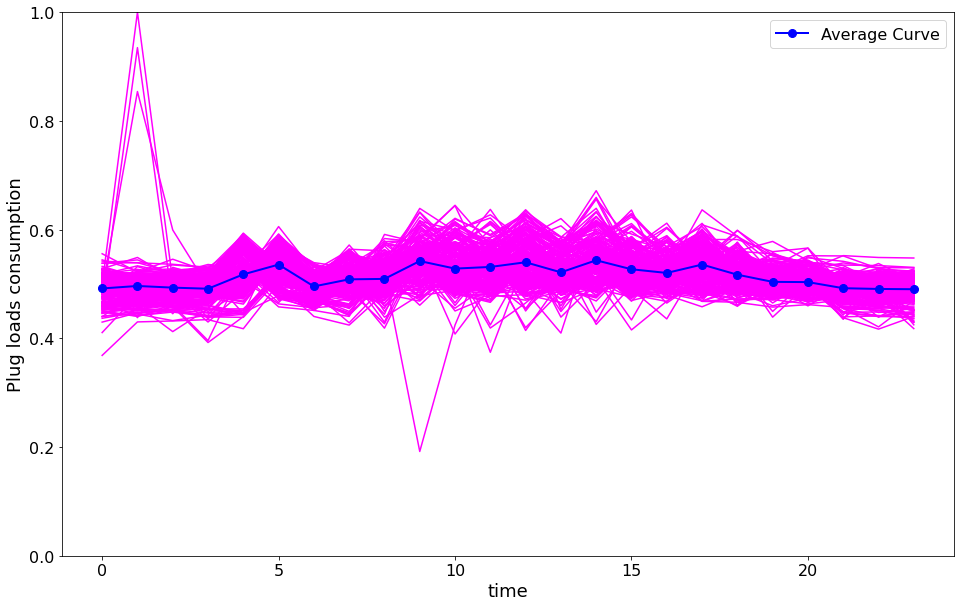

<Figure size 432x288 with 0 Axes>

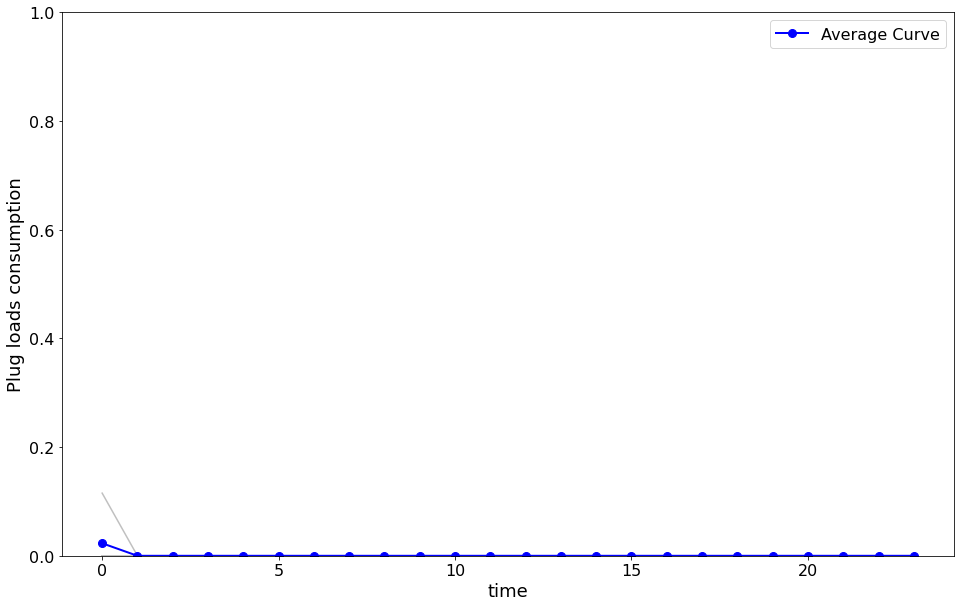

<Figure size 432x288 with 0 Axes>

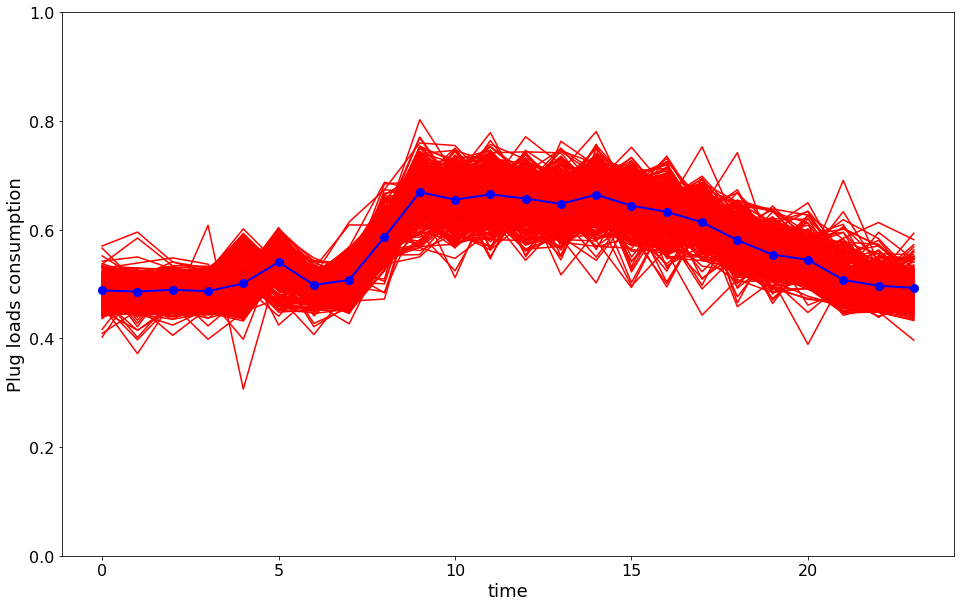

<Figure size 432x288 with 0 Axes>

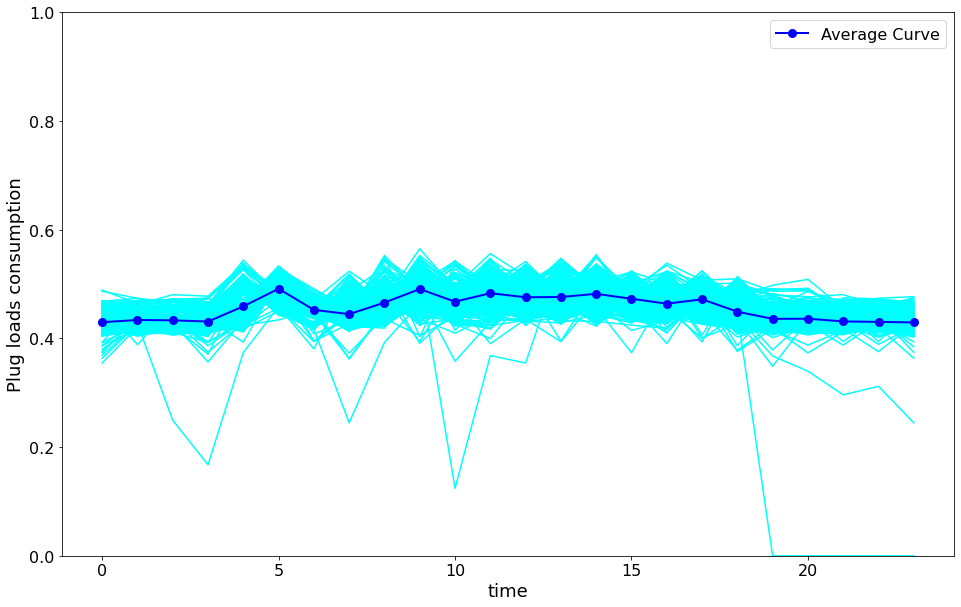

In [112]:
#with divided data for Plug loads ==>  N=5 [2,0,4,1,3]

plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels1.shape[0]):
    if Dayly_Plug_loads_labels1[i]==0: 
        plt.plot(scaled_data_Plug_loads[i], color = 'black') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels1 == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Plug loads-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels1.shape[0]): 
    if Dayly_Plug_loads_labels1[i]==1: 
        plt.plot(scaled_data_Plug_loads[i], color = 'magenta') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels1 == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels1.shape[0]): 
    if Dayly_Plug_loads_labels1[i]==2: 
        plt.plot(scaled_data_Plug_loads[i], color = 'silver')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels1 == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels1.shape[0]): 
    if Dayly_Plug_loads_labels1[i]==3: 
        plt.plot(scaled_data_Plug_loads[i], color = 'red')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels1 == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
# plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels1.shape[0]): 
    if Dayly_Plug_loads_labels1[i]==4: 
        plt.plot(scaled_data_Plug_loads[i], color = 'cyan')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels1 == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 5")
        
# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==5: 
#        plt.plot(scaled_data_sumx[i], color = 'red')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 6")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==6: 
#        plt.plot(scaled_data_sumx[i], color = 'yellow')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 7")

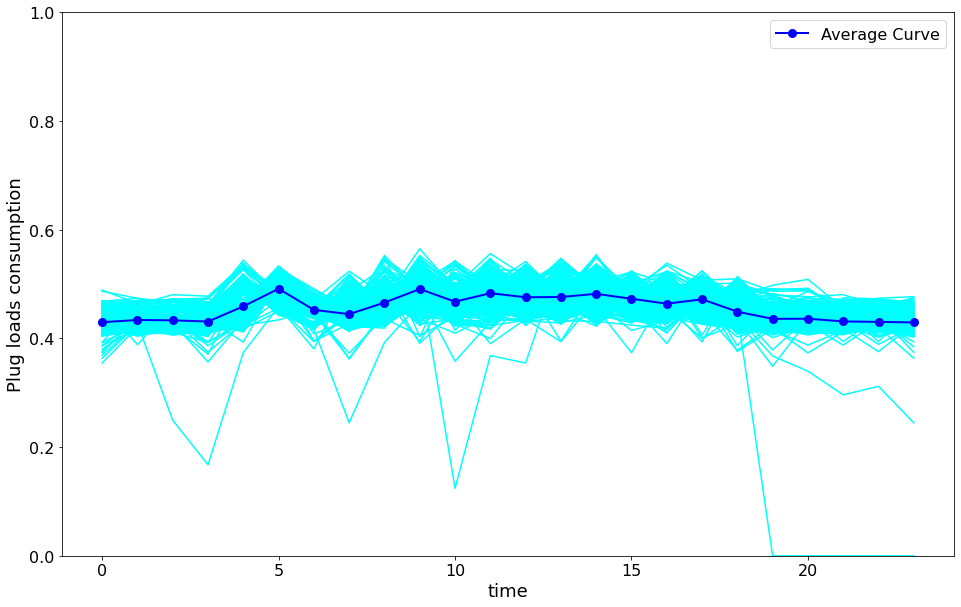

<Figure size 432x288 with 0 Axes>

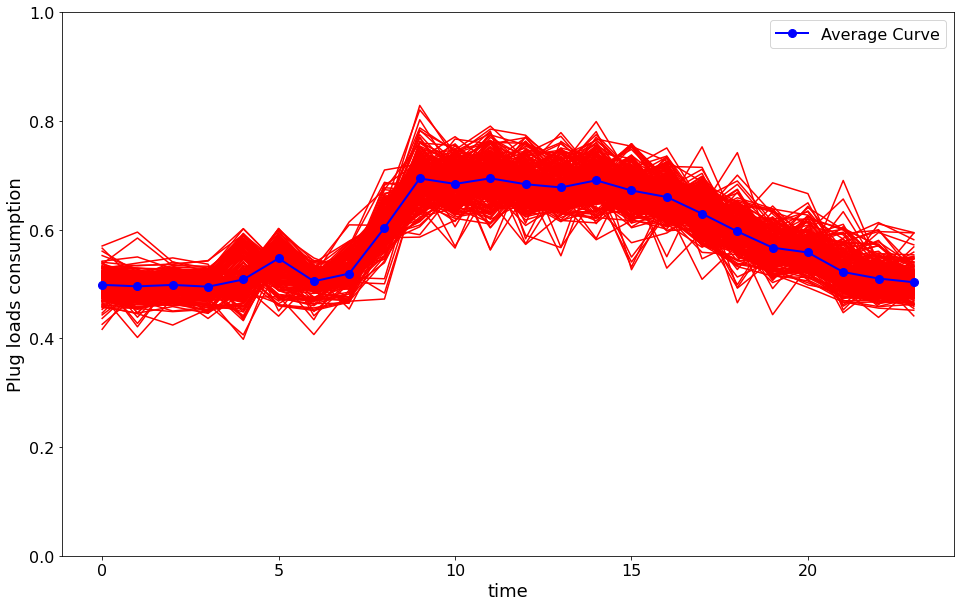

<Figure size 432x288 with 0 Axes>

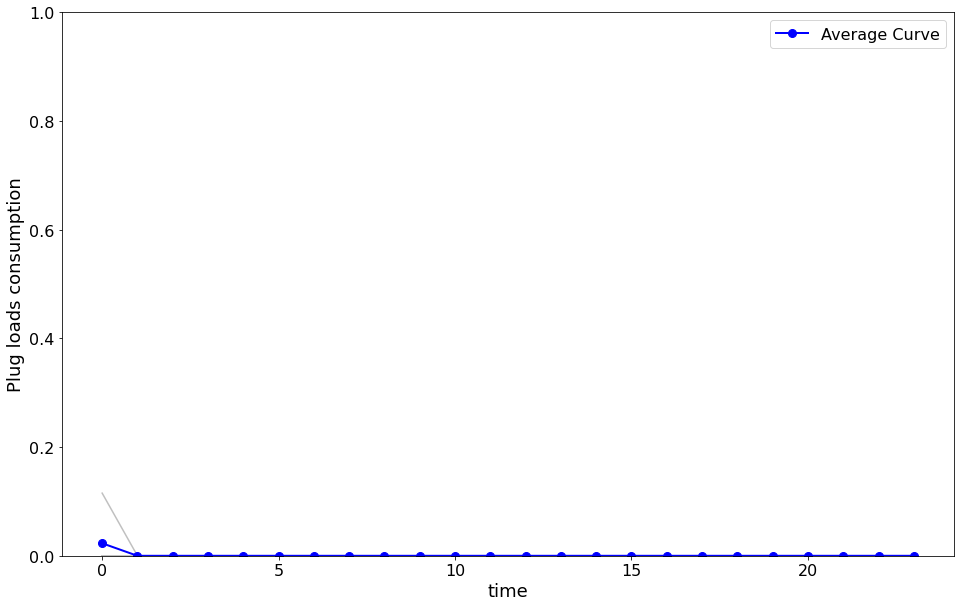

<Figure size 432x288 with 0 Axes>

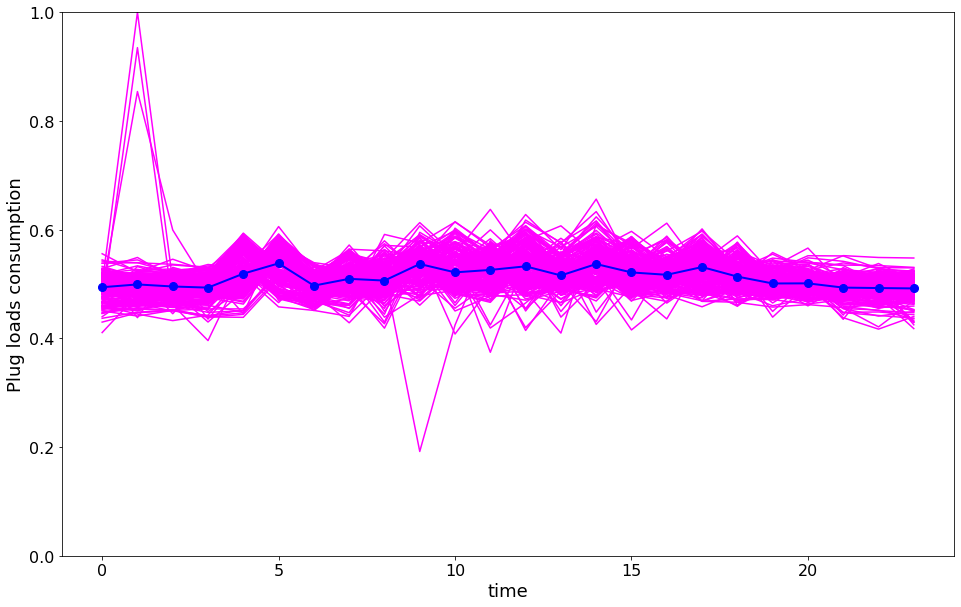

<Figure size 432x288 with 0 Axes>

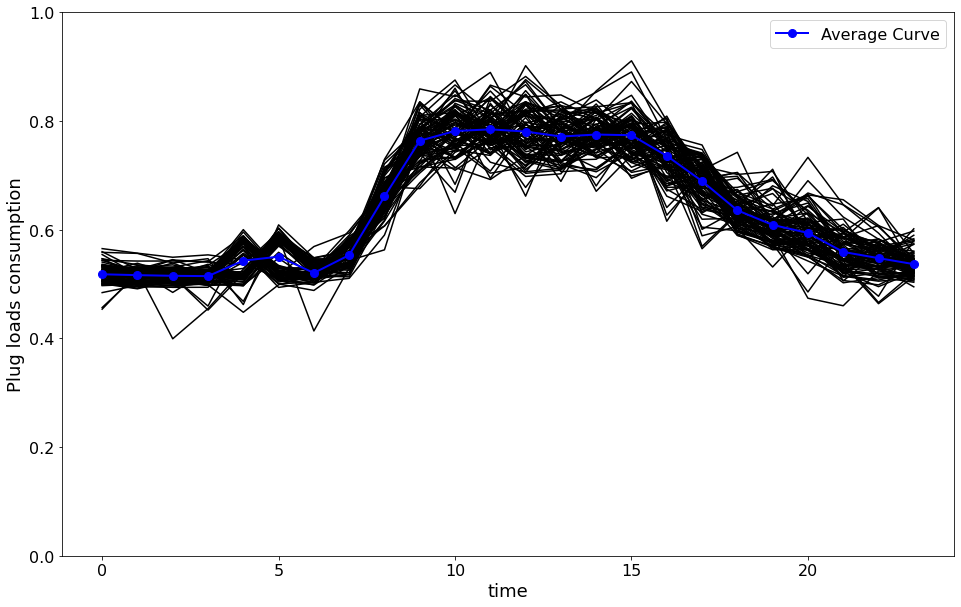

<Figure size 432x288 with 0 Axes>

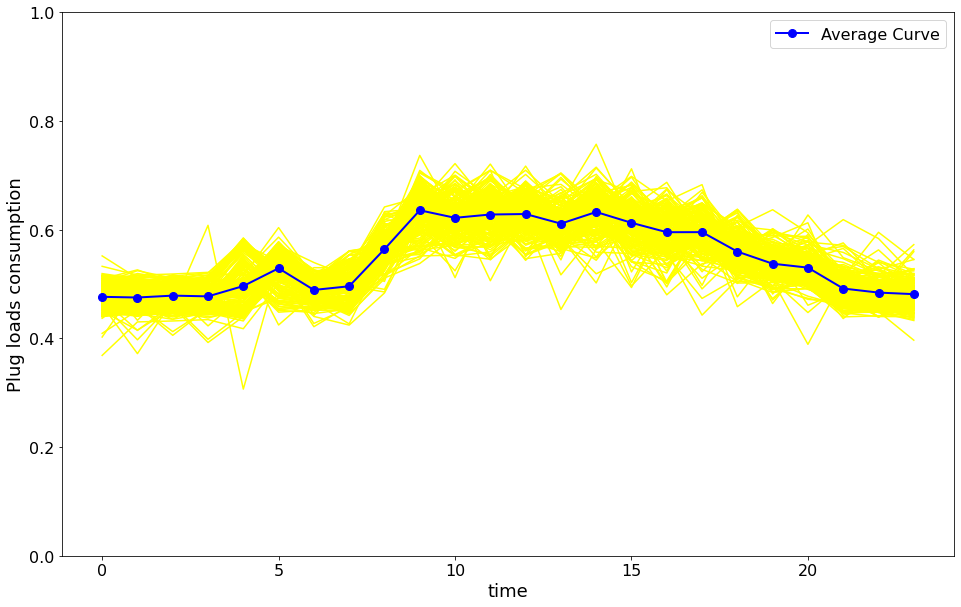

In [125]:
#with divided data for Plug loads ==>  N=6 ['cyan','red','silver','magenta','black',yellow]

plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]):
    if Dayly_Plug_loads_labels2[i]==0: 
        plt.plot(scaled_data_Plug_loads[i], color = 'cyan') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 0], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
# plt.title("Plug loads-Cluster 1")

plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]): 
    if Dayly_Plug_loads_labels2[i]==1: 
        plt.plot(scaled_data_Plug_loads[i], color = 'red') 
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 1], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 2")
       
plt.figure() 
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]): 
    if Dayly_Plug_loads_labels2[i]==2: 
        plt.plot(scaled_data_Plug_loads[i], color = 'silver')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 2], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 3") 

plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]): 
    if Dayly_Plug_loads_labels2[i]==3: 
        plt.plot(scaled_data_Plug_loads[i], color = 'magenta')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 3], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
# plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 4")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]): 
    if Dayly_Plug_loads_labels2[i]==4: 
        plt.plot(scaled_data_Plug_loads[i], color = 'black')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 4], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()
# plt.title("Plug loads-Cluster 5")
        
plt.figure()
plt.figure(figsize=(16, 10))
for i in range(Dayly_Plug_loads_labels2.shape[0]): 
    if Dayly_Plug_loads_labels2[i]==5: 
        plt.plot(scaled_data_Plug_loads[i], color = 'yellow')  
        plt.ylim(0, 1)
average_curve = np.mean(scaled_data_Plug_loads[Dayly_Plug_loads_labels2 == 5], axis=0)  # Calculate mean only for relevant curves
plt.plot(average_curve, color='blue', linewidth=2, marker='o', markersize=8, label='Average Curve')  # Plot average in blue with thicker line
# plt.plot(average_curve, color='blue', linewidth=2, label='Average Curve')  # Plot average in blue with thicker line
plt.xlabel("time",fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("Plug loads consumption",fontsize=18)
plt.yticks(fontsize=16)
# Optional: Add a legend
plt.legend(fontsize=16)
# Show the plot
plt.show()   
#        plt.title("Energy-Cluster 6")

# plt.figure()
# plt.figure(figsize=(16, 10))
# for i in range(Dayly_Energy_labels1.shape[0]): 
#    if Dayly_Energy_labels1[i]==6: 
#        plt.plot(scaled_data_sumx[i], color = 'yellow')  
#        plt.xlabel("time") 
#        plt.ylabel("Energy consumption")   
#        plt.title("Energy-Cluster 7")

In [114]:
dates = pd.date_range(start='2021-01-01', periods=1095, freq='D')
dates = dates.astype(object)

# Concatenate the date column with the original array horizontally
data_with_date = np.hstack((np.expand_dims(dates, axis=1), HVAC))
Data_with_date_normalize = np.hstack((np.expand_dims(dates, axis=1), scaled_data_HVAC))
DF_N=pd.DataFrame(Data_with_date_normalize)
DF_=pd.DataFrame(data_with_date)
DF_
# df = pd.DataFrame(data_with_date)
# df1= df.drop(df[df[0]=='2021-04-19'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-04-20'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-06-04'].index[0])
# df1=df1.drop(df1[df1[0]=='2021-12-31'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-02-03'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-07-13'].index[0])
# df1=df1.drop(df1[df1[0]=='2022-12-31'].index[0])
# Df1=df1
# Df1['Cluster_energy'] = Dayly_Energy_labels
# Df1

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,2021-01-01,30.48,28.149,32.494,54.825,78.908,80.322,72.291,55.901,52.659,...,42.621,41.87,41.938,39.905,28.345,52.319,26.645,26.673,25.202,24.325
1,2021-01-02,24.705,26.034,24.901,25.919,24.512,23.97,23.444,21.136,20.464,...,18.378,19.353,20.249,18.747,20.023,19.781,19.698,21.625,20.201,20.859
2,2021-01-03,18.52,20.106,21.061,22.215,20.638,22.136,21.208,20.833,23.537,...,18.79,18.516,22.009,18.747,19.294,21.052,21.065,20.737,28.196,41.356
3,2021-01-04,43.129,44.601,44.905,42.34,81.072,107.67,69.827,62.727,50.28,...,38.491,62.841,49.743,40.215,28.841,26.175,24.499,24.484,24.094,25.114
4,2021-01-05,25.83,23.672,25.641,26.336,87.401,73.397,60.02,60.508,58.912,...,52.951,51.92,49.529,51.646,42.96,43.023,41.83,30.064,34.695,34.654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2023-12-27,25.415,25.021,29.798,27.73,39.737,33.418,34.26,43.187,40.592,...,35.032,33.805,37.52,32.286,26.021,26.301,23.147,25.474,24.387,22.197
1091,2023-12-28,27.727,26.143,30.586,27.04,35.835,32.185,33.018,40.983,32.722,...,31.152,36.74,32.093,32.144,26.609,26.564,23.163,25.496,25.325,25.361
1092,2023-12-29,26.341,26.529,30.698,27.506,38.518,33.567,34.448,39.235,41.029,...,37.0,37.705,40.651,35.944,25.962,25.472,23.214,25.555,26.973,24.65
1093,2023-12-30,24.927,26.353,26.449,26.709,26.274,24.833,23.381,23.101,21.11,...,22.634,20.304,20.055,18.854,23.088,20.045,23.078,21.193,22.195,21.367


In [115]:
DF_['Cluster_energy'] = Dayly_HVAC_labels1
DF_N['Cluster_energy'] = Dayly_HVAC_labels1
DF_[DF_['Cluster_energy']==4]

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,Cluster_energy
35,2021-02-05,24.015,23.888,25.493,26.548,51.465,68.692,53.733,51.402,44.395,...,45.244,50.052,51.649,40.492,45.075,36.279,38.584,34.855,42.141,4
59,2021-03-01,31.79,39.244,37.809,38.721,75.109,61.962,54.881,51.614,47.884,...,51.02,67.203,40.447,33.675,32.154,32.063,33.416,37.961,39.556,4
138,2021-05-19,31.452,31.758,31.257,30.556,44.651,42.414,39.493,41.416,39.722,...,53.146,47.178,43.857,36.514,41.65,35.024,33.986,31.648,31.879,4
139,2021-05-20,33.471,29.889,33.895,30.93,48.784,45.097,42.89,43.071,44.213,...,53.217,55.143,54.364,48.006,46.161,37.257,30.814,31.694,31.92,4
140,2021-05-21,29.806,32.455,30.575,31.384,48.319,44.607,44.203,43.157,43.686,...,45.081,58.019,52.219,39.485,36.606,33.135,32.509,33.92,32.202,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1026,2023-10-24,26.708,24.612,35.778,32.921,34.372,35.252,35.504,36.833,38.576,...,54.175,55.105,56.711,29.347,29.708,27.445,26.671,25.524,27.619,4
1027,2023-10-25,27.058,28.096,48.559,44.779,42.956,39.668,42.528,43.783,46.651,...,59.932,59.992,57.265,30.362,26.068,27.358,27.705,25.199,27.143,4
1028,2023-10-26,27.301,26.794,49.661,45.961,40.046,40.053,43.993,43.629,35.737,...,61.066,57.126,53.292,31.288,28.99,27.029,27.151,27.22,26.999,4
1029,2023-10-27,24.61,28.093,48.345,44.066,42.006,41.023,42.69,43.872,43.06,...,54.91,54.282,49.688,29.531,30.705,26.174,26.655,27.906,27.241,4


In [45]:
consumption_cl1=DF_[DF_["Cluster_energy"]==0] 
consumption_cl1=consumption_cl1.drop('Cluster_energy', axis=1)
consumption_cl1_df=consumption_cl1
consumption_cl1=consumption_cl1.drop(0, axis=1) 
consumption_cl1=consumption_cl1.values

consumption_cl2=DF_[DF_["Cluster_energy"]==1] 
consumption_cl2=consumption_cl2.drop('Cluster_energy', axis=1)
consumption_cl2_df=consumption_cl2
consumption_cl2=consumption_cl2.drop(0, axis=1) 
consumption_cl2=consumption_cl2.values

consumption_cl3=DF_[DF_["Cluster_energy"]==2] 
consumption_cl3=consumption_cl3.drop('Cluster_energy', axis=1)
consumption_cl3_df=consumption_cl3
consumption_cl3=consumption_cl3.drop(0, axis=1) 
consumption_cl3=consumption_cl3.values

consumption_cl4=DF_[DF_["Cluster_energy"]==3] 
consumption_cl4=consumption_cl4.drop('Cluster_energy', axis=1)
consumption_cl4_df=consumption_cl4
consumption_cl4=consumption_cl4.drop(0, axis=1) 
consumption_cl4=consumption_cl4.values

consumption_cl5=DF_[DF_["Cluster_energy"]==4] 
consumption_cl5=consumption_cl5.drop('Cluster_energy', axis=1)
consumption_cl5_df=consumption_cl5
consumption_cl5=consumption_cl5.drop(0, axis=1) 
consumption_cl5=consumption_cl5.values

# consumption_cl6=DF_[DF_["Cluster_energy"]==6] 
# consumption_cl6=consumption_cl6.drop('Cluster_energy', axis=1)
# consumption_cl6_df=consumption_cl6
# consumption_cl6=consumption_cl6.drop(0, axis=1) 
# consumption_cl6=consumption_cl6.values

consumption_cl5_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
1,2021-01-02,24.705,26.034,24.901,25.919,24.512,23.97,23.444,21.136,20.464,...,18.378,19.353,20.249,18.747,20.023,19.781,19.698,21.625,20.201,20.859
2,2021-01-03,18.52,20.106,21.061,22.215,20.638,22.136,21.208,20.833,23.537,...,18.79,18.516,22.009,18.747,19.294,21.052,21.065,20.737,28.196,41.356
8,2021-01-09,37.038,39.002,39.181,42.298,37.858,33.659,29.42,27.454,26.918,...,22.221,22.466,24.383,23.869,26.376,25.214,24.499,24.802,26.171,27.147
9,2021-01-10,25.358,26.258,26.76,26.274,27.952,26.634,27.051,26.898,26.637,...,24.14,23.628,25.167,27.415,24.584,25.706,26.871,27.971,40.636,47.975
15,2021-01-16,29.153,31.7,28.903,26.642,30.62,30.637,27.695,24.553,24.864,...,24.347,24.285,23.797,24.447,23.114,24.218,23.687,24.937,24.668,24.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,2023-05-07,21.628,19.899,22.536,22.955,20.667,21.979,20.385,21.82,22.174,...,20.558,21.853,21.809,19.32,22.204,22.998,20.208,22.1,19.265,22.561
862,2023-05-13,28.315,26.153,28.01,28.358,28.616,27.488,26.124,21.841,22.052,...,22.352,22.609,21.562,21.924,23.399,23.286,22.998,22.287,22.529,18.961
863,2023-05-14,21.923,21.705,20.886,23.41,19.921,22.096,19.187,22.889,23.243,...,21.531,22.679,21.905,21.425,22.243,22.196,20.656,21.792,21.85,21.825
869,2023-05-20,28.768,26.617,28.626,28.746,25.335,27.031,28.217,22.752,20.688,...,22.049,21.757,20.865,23.077,20.356,22.289,22.877,20.338,23.055,23.104


In [46]:
consumption_cl1_N=DF_N[DF_N["Cluster_energy"]==0] 
consumption_cl1_N=consumption_cl1_N.drop('Cluster_energy', axis=1)
consumption_cl1_df_N=consumption_cl1_N
consumption_cl1_N=consumption_cl1_N.drop(0, axis=1) 
consumption_cl1_N=consumption_cl1_N.values

consumption_cl2_N=DF_N[DF_N["Cluster_energy"]==1] 
consumption_cl2_N=consumption_cl2_N.drop('Cluster_energy', axis=1)
consumption_cl2_df_N=consumption_cl2_N
consumption_cl2_N=consumption_cl2_N.drop(0, axis=1) 
consumption_cl2_N=consumption_cl2_N.values

consumption_cl3_N=DF_N[DF_N["Cluster_energy"]==2] 
consumption_cl3_N=consumption_cl3_N.drop('Cluster_energy', axis=1)
consumption_cl3_N_df=consumption_cl3_N
consumption_cl3_N=consumption_cl3_N.drop(0, axis=1) 
consumption_cl3_N=consumption_cl3_N.values

consumption_cl4_N=DF_N[DF_N["Cluster_energy"]==3] 
consumption_cl4_N=consumption_cl4_N.drop('Cluster_energy', axis=1)
consumption_cl4_N_df=consumption_cl4_N
consumption_cl4_N=consumption_cl4_N.drop(0, axis=1) 
consumption_cl4_N=consumption_cl4_N.values

consumption_cl5_N=DF_N[DF_N["Cluster_energy"]==4] 
consumption_cl5_N=consumption_cl5_N.drop('Cluster_energy', axis=1)
consumption_cl5_N_df=consumption_cl5_N
consumption_cl5_N=consumption_cl5_N.drop(0, axis=1) 
consumption_cl5_N=consumption_cl5_N.values

# consumption_cl6_N=DF_N[DF_N["Cluster_energy"]==6] 
# consumption_cl6_N=consumption_cl6_N.drop('Cluster_energy', axis=1)
# consumption_cl6_N_df=consumption_cl6_N
# consumption_cl6_N=consumption_cl6_N.drop(0, axis=1) 
# consumption_cl6_N=consumption_cl6_N.values

consumption_cl5_N_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
1,2021-01-02,0.157509,0.165982,0.158759,0.165249,0.156279,0.152823,0.14947,0.134755,0.13047,...,0.117171,0.123387,0.1291,0.119523,0.127659,0.126116,0.125587,0.137872,0.128793,0.132989
2,2021-01-03,0.118076,0.128188,0.134276,0.141634,0.13158,0.14113,0.135214,0.132823,0.150062,...,0.119798,0.118051,0.140321,0.119523,0.123011,0.134219,0.134302,0.132211,0.179766,0.263669
8,2021-01-09,0.236139,0.248661,0.249802,0.269675,0.241367,0.214596,0.18757,0.175036,0.171618,...,0.141672,0.143234,0.155456,0.152179,0.168163,0.160754,0.156196,0.158128,0.166856,0.173078
9,2021-01-10,0.161672,0.16741,0.170611,0.167512,0.178211,0.169808,0.172466,0.171491,0.169827,...,0.153907,0.150643,0.160455,0.174787,0.156738,0.163891,0.171319,0.178332,0.259079,0.305869
15,2021-01-16,0.185868,0.202106,0.184274,0.169859,0.195221,0.195329,0.176572,0.15654,0.158523,...,0.155227,0.154831,0.15172,0.155864,0.147366,0.154404,0.151019,0.158988,0.157273,0.15786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,2023-05-07,0.137891,0.126868,0.143681,0.146352,0.131765,0.140129,0.129967,0.139116,0.141373,...,0.13107,0.139326,0.139045,0.123177,0.141564,0.146626,0.128838,0.140901,0.122826,0.14384
862,2023-05-13,0.180525,0.166741,0.178581,0.180799,0.182444,0.175252,0.166556,0.139249,0.140595,...,0.142507,0.144146,0.137471,0.139779,0.149183,0.148462,0.146626,0.142093,0.143636,0.120888
863,2023-05-14,0.139772,0.138382,0.133161,0.149253,0.127008,0.140875,0.122329,0.145931,0.148188,...,0.137273,0.144592,0.139658,0.136597,0.141812,0.141513,0.131694,0.138937,0.139307,0.139147
869,2023-05-20,0.183413,0.169699,0.182508,0.183273,0.161526,0.172339,0.1799,0.145058,0.131898,...,0.140576,0.138714,0.133027,0.14713,0.129782,0.142106,0.145855,0.129667,0.146989,0.147302


In [47]:
Temprature_cluster=pd.DataFrame(Temp_2)
Temprature_cluster['Cluster_energy'] = Dayly_HVAC_labels1

Temp_cl1=Temprature_cluster[Temprature_cluster["Cluster_energy"]==0]
Temp_cl1=Temp_cl1.drop('Cluster_energy', axis=1)
Temp_cl1=Temp_cl1.values

Temp_cl2=Temprature_cluster[Temprature_cluster["Cluster_energy"]==1]
Temp_cl2=Temp_cl2.drop('Cluster_energy', axis=1)
Temp_cl2=Temp_cl2.values

Temp_cl3=Temprature_cluster[Temprature_cluster["Cluster_energy"]==2]
Temp_cl3=Temp_cl3.drop('Cluster_energy', axis=1)
Temp_cl3=Temp_cl3.values

Temp_cl4=Temprature_cluster[Temprature_cluster["Cluster_energy"]==3]
Temp_cl4=Temp_cl4.drop('Cluster_energy', axis=1)
Temp_cl4=Temp_cl4.values

Temp_cl5=Temprature_cluster[Temprature_cluster["Cluster_energy"]==4]
Temp_cl5=Temp_cl5.drop('Cluster_energy', axis=1)
Temp_cl5=Temp_cl5.values

# Temp_cl6=Temprature_cluster[Temprature_cluster["Cluster_energy"]==6]
# Temp_cl6=Temp_cl6.drop('Cluster_energy', axis=1)
# Temp_cl6=Temp_cl6.values
Temp_cl5.shape

(252, 24)

In [48]:
# Temp_cl7=Temprature_cluster[Temprature_cluster["Cluster_energy"]==4]
# Temp_cl7=Temp_cl7.drop('Cluster_energy', axis=1)
# Temp_cl7=Temp_cl7.values
# Temp_cl7.shape

In [49]:

Radiation_cluster=pd.DataFrame(Radiation_2)
Radiation_cluster['Cluster_energy'] = Dayly_HVAC_labels1

Rad_cl1=Radiation_cluster[Radiation_cluster["Cluster_energy"]==0]
Rad_cl1=Rad_cl1.drop('Cluster_energy', axis=1)
Rad_cl1=Rad_cl1.values

Rad_cl2=Radiation_cluster[Radiation_cluster["Cluster_energy"]==1]
Rad_cl2=Rad_cl2.drop('Cluster_energy', axis=1)
Rad_cl2=Rad_cl2.values

Rad_cl3=Radiation_cluster[Radiation_cluster["Cluster_energy"]==2]
Rad_cl3=Rad_cl3.drop('Cluster_energy', axis=1)
Rad_cl3=Rad_cl3.values

Rad_cl4=Radiation_cluster[Radiation_cluster["Cluster_energy"]==3]
Rad_cl4=Rad_cl4.drop('Cluster_energy', axis=1)
Rad_cl4=Rad_cl4.values

Rad_cl5=Radiation_cluster[Radiation_cluster["Cluster_energy"]==4]
Rad_cl5=Rad_cl5.drop('Cluster_energy', axis=1)
Rad_cl5=Rad_cl5.values

# Rad_cl6=Radiation_cluster[Radiation_cluster["Cluster_energy"]==6]
# Rad_cl6=Rad_cl6.drop('Cluster_energy', axis=1)
# Rad_cl6=Rad_cl6.values
Rad_cl5.shape

(252, 24)

In [198]:
import calmap

all_days = pd.date_range('01/01/2021', periods=HVAC.shape[0], freq='D')
days = np.random.choice(all_days, 1095)
#events = pd.Series(Dayly_Energy_labels, index=all_days)
# events = pd.Series(df1["Cluster_energy"].values, index=df1[0])
eventsHVAC = pd.Series(DF_["Cluster_energy"].values, index=DF_[0])
eventsLighting = pd.Series(Dayly_Lighting_labels1, index=DF_[0])
eventsPlug_loads = pd.Series(Dayly_Plug_loads_labels1, index=DF_[0])
eventsPlug_loads2 = pd.Series(Dayly_Plug_loads_labels2, index=DF_[0])
eventsOcc_consumption = pd.Series(Occ_consumption_labels, index=DF_[0])

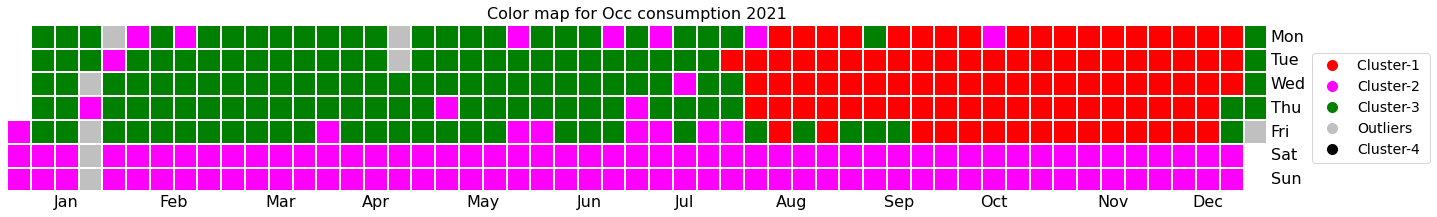

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

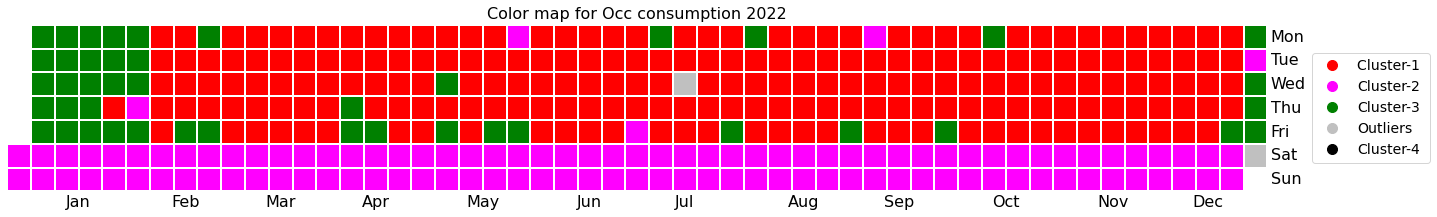

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

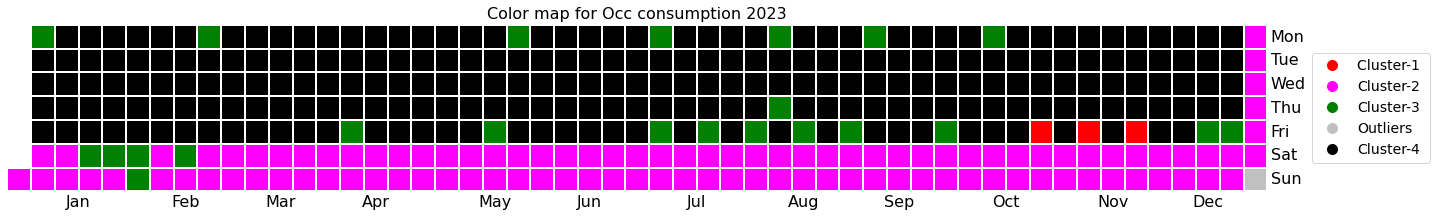

In [200]:
#Colmap for data for Occ consumption
from matplotlib import colors

#Heat mape for 2021
cm_colors = ['red','magenta','green','silver','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3','Outliers' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsOcc_consumption, year=2021, cmap=cmap, vmin=eventsOcc_consumption.min(), vmax=eventsOcc_consumption.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,4,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Occ consumption 2021',fontsize=16)
fig.tight_layout()


#Heat mape for 2022
plt.figure()
plt.figure()
cm_colors = ['red','magenta','green','silver','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3','Outliers' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsOcc_consumption, year=2022, cmap=cmap, vmin=eventsOcc_consumption.min(), vmax=eventsOcc_consumption.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,4,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Occ consumption 2022',fontsize=16)
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors = ['red','magenta','green','silver','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3','Outliers' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsOcc_consumption, year=2023, cmap=cmap, vmin=eventsOcc_consumption.min(), vmax=eventsOcc_consumption.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,4,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Occ consumption 2023',fontsize=16)
fig.tight_layout()

<AxesSubplot:>

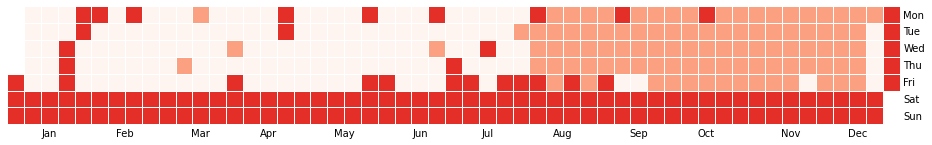

<Figure size 432x288 with 0 Axes>

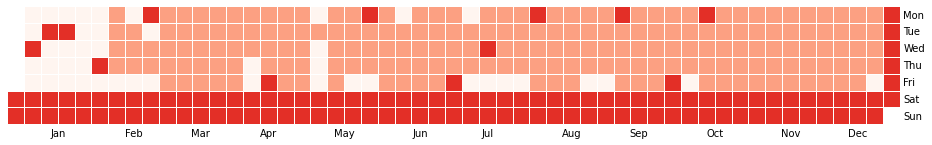

<Figure size 432x288 with 0 Axes>

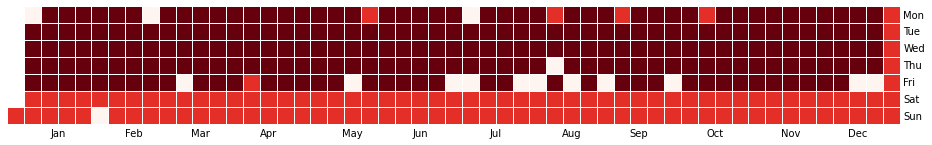

In [117]:
#calmap for lighting 
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsLighting, year=2021)

plt.figure()
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsLighting, year=2022)

plt.figure()
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsLighting, year=2023)

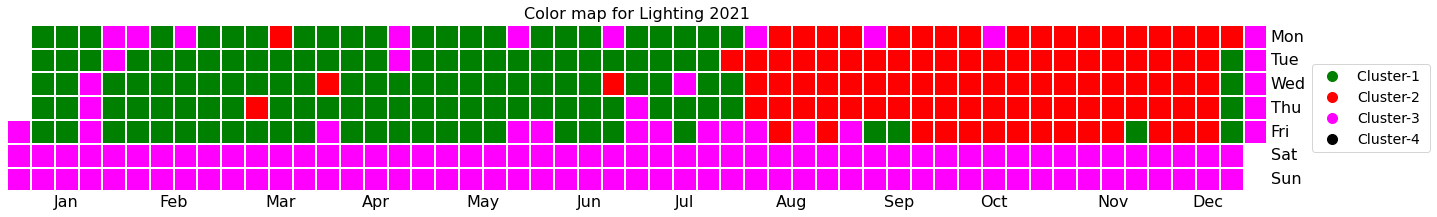

<Figure size 432x288 with 0 Axes>

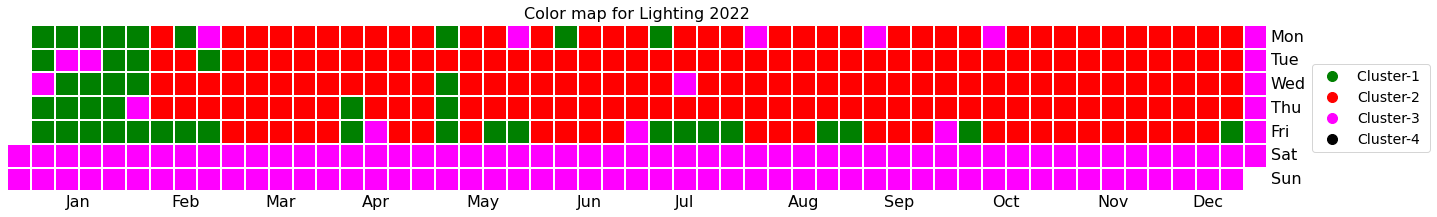

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 1728x1152 with 0 Axes>

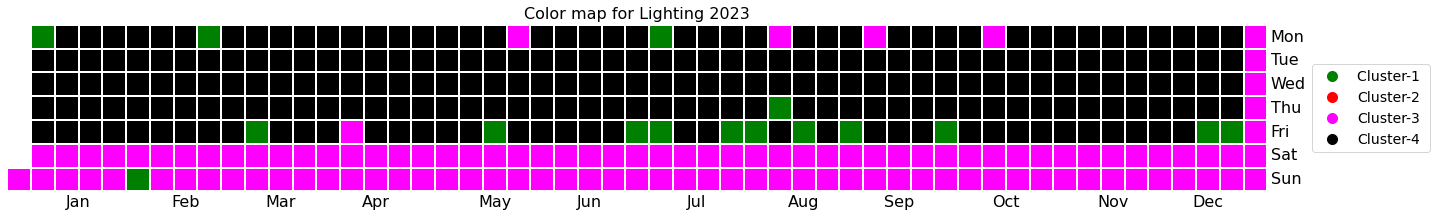

In [159]:
#Colmap for data for Lighting
from matplotlib import colors

#Heat mape for 2021
cm_colors = ['green','red','magenta','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsLighting, year=2021, cmap=cmap, vmin=eventsLighting.min(), vmax=eventsLighting.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Lighting 2021',fontsize=16)
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = ['green','red','magenta','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsLighting, year=2022, cmap=cmap, vmin=eventsLighting.min(), vmax=eventsLighting.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Lighting 2022',fontsize=16)
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors =['green','red','magenta','black']
cm_labels = ['Cluster-1 ', 'Cluster-2','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsLighting, year=2023, cmap=cmap, vmin=eventsLighting.min(), vmax=eventsLighting.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for Lighting 2023',fontsize=16)
fig.tight_layout()

<AxesSubplot:>

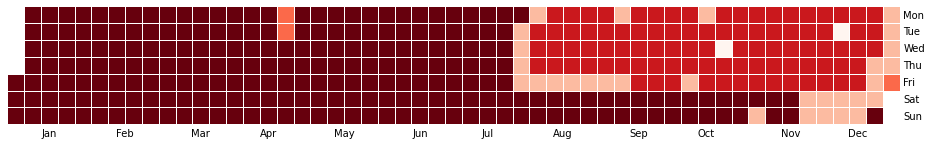

<Figure size 432x288 with 0 Axes>

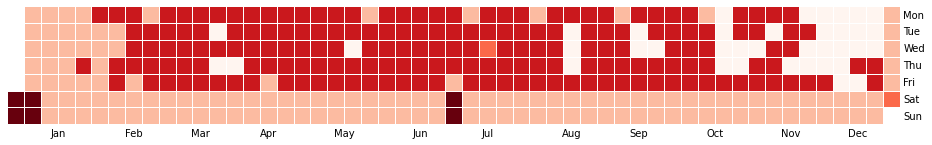

<Figure size 432x288 with 0 Axes>

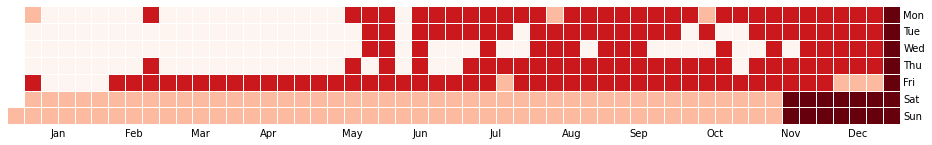

In [120]:
#calmap for Plug loads 
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsPlug_loads, year=2021)

plt.figure()
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsPlug_loads, year=2022)

plt.figure()
plt.figure(figsize=(16, 10))
calmap.yearplot(eventsPlug_loads, year=2023)

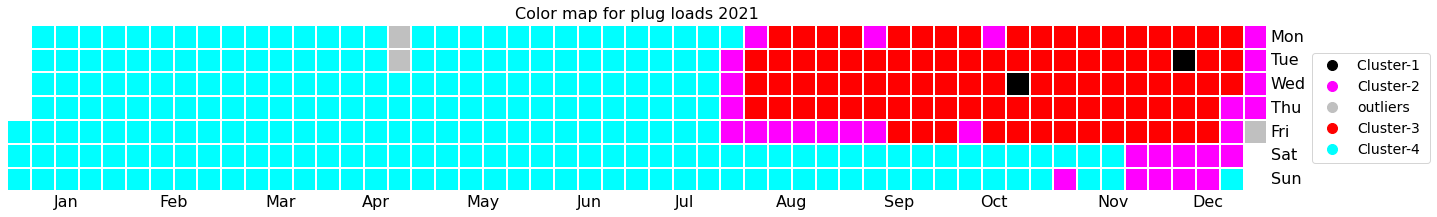

<Figure size 432x288 with 0 Axes>

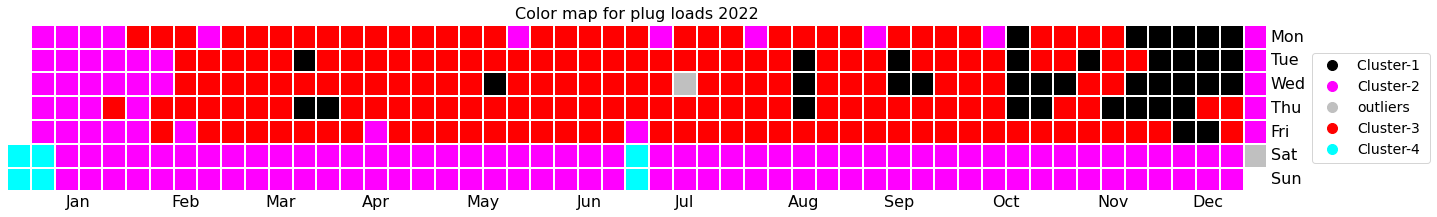

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 1728x1152 with 0 Axes>

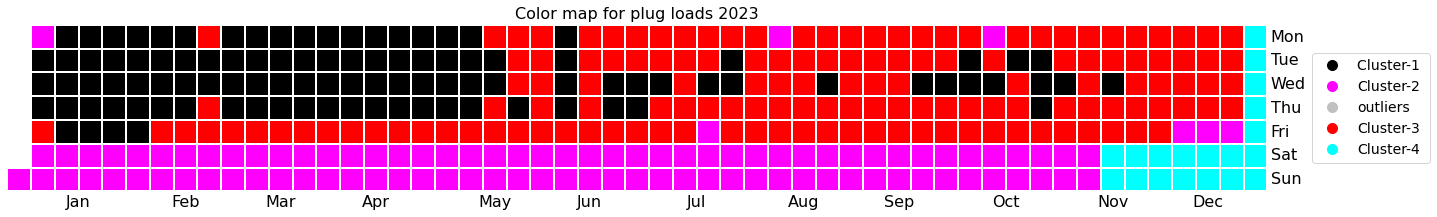

In [156]:
#Colmap for data for Plug loads
from matplotlib import colors

#Heat mape for 2021
cm_colors = ['black','magenta','silver','red','cyan']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsPlug_loads, year=2021, cmap=cmap, vmin=eventsPlug_loads.min(), vmax=eventsPlug_loads.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for plug loads 2021',fontsize=16)
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = ['black','magenta','silver','red','cyan']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsPlug_loads, year=2022, cmap=cmap, vmin=eventsPlug_loads.min(), vmax=eventsPlug_loads.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for plug loads 2022',fontsize=16)
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors =['black','magenta','silver','red','cyan']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsPlug_loads, year=2023, cmap=cmap, vmin=eventsPlug_loads.min(), vmax=eventsPlug_loads.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('Color map for plug loads 2023',fontsize=16)
fig.tight_layout()

Text(0.5, 1.0, 'Color map for plug loads 2023')

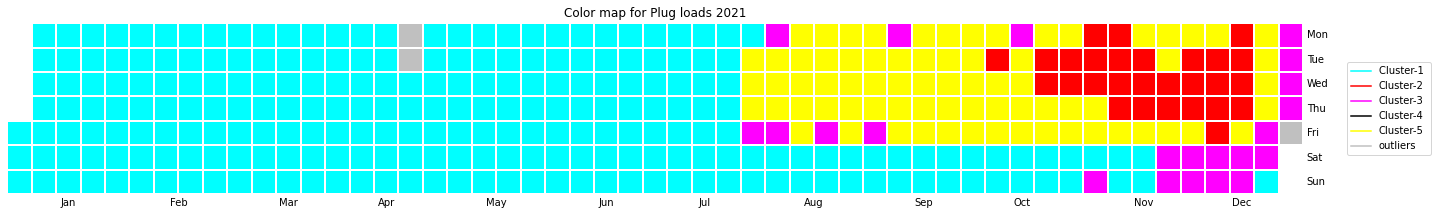

<Figure size 432x288 with 0 Axes>

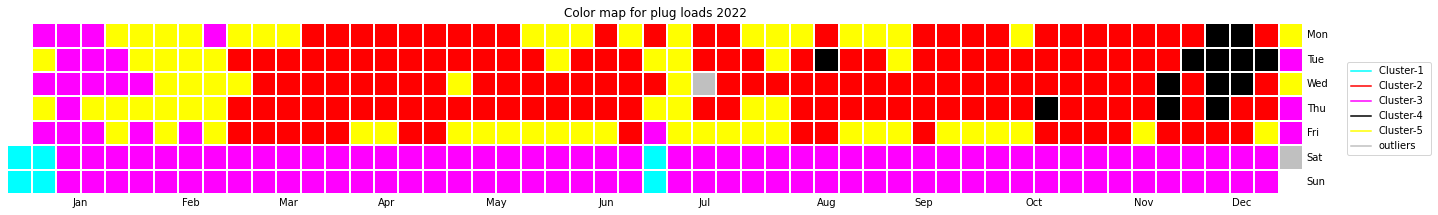

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 1728x1152 with 0 Axes>

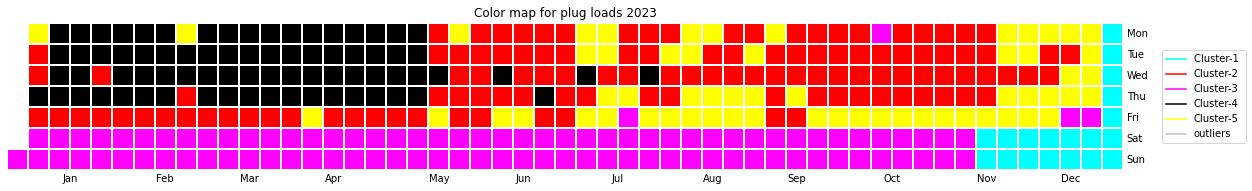

In [128]:
#Colmap for data for Plug loads2
from matplotlib import colors

#Heat mape for 2021
cm_colors = ['cyan','red','silver','magenta','black','yellow']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4', 'Cluster-5']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsPlug_loads2, year=2021, cmap=cmap, vmin=eventsPlug_loads2.min(), vmax=eventsPlug_loads2.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,2]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('Color map for Plug loads 2021')
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = ['cyan','red','silver','magenta','black','yellow']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4', 'Cluster-5']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsPlug_loads2, year=2022, cmap=cmap, vmin=eventsPlug_loads2.min(), vmax=eventsPlug_loads2.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,2]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('Color map for plug loads 2022')
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors = ['cyan','red','silver','magenta','black','yellow']
cm_labels = ['Cluster-1 ', 'Cluster-2','outliers','Cluster-3' , 'Cluster-4', 'Cluster-5']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsPlug_loads2, year=2023, cmap=cmap, vmin=eventsPlug_loads2.min(), vmax=eventsPlug_loads2.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,3,4,5,2]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('Color map for plug loads 2023')

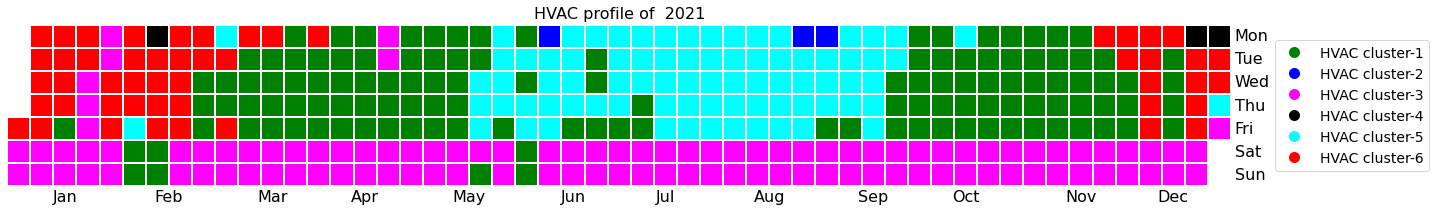

<Figure size 432x288 with 0 Axes>

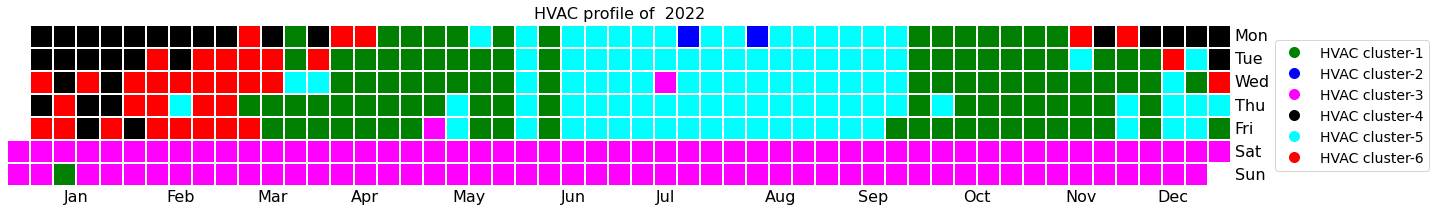

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 1728x1152 with 0 Axes>

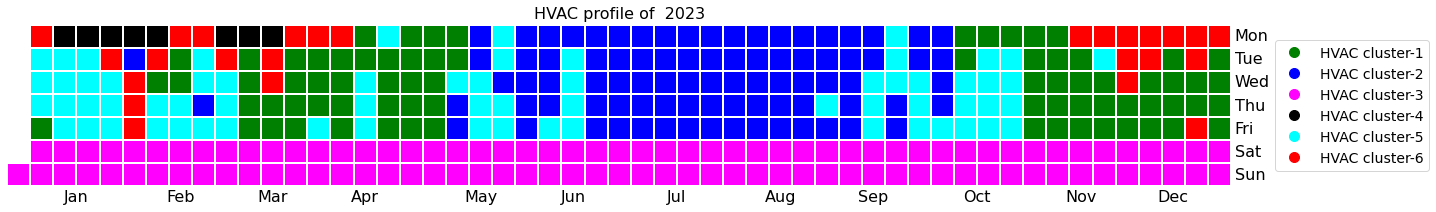

In [164]:
#Colmap for HVAC
from matplotlib import colors

#Heat mape for 2023
# The colors and labels could be used from elsewhere as long as they are of the same size
# cm_colors = [ 'green','magenta','black','cyan','silver','red','yellow']
# cm_labels = ['Moderate weather consumption', 'Holiday and weekend','Winter start of the weekdays consumption', 'Cooling priod consumption' ,
#              'Outliers','After COVIV19 winter consumption',' During COVIV19 winter consumption']
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsHVAC, year=2021, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('HVAC profile of  2021',fontsize=16)
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsHVAC, year=2022, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('HVAC profile of  2022',fontsize=16)
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsHVAC, year=2023, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# Set the font size of the month names and days of the week
ax.xaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the month names (x-axis)
ax.yaxis.set_tick_params(labelsize=16)  # Adjusts the font size of the days of the week (y-axis)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
order = [0,1,2,3,4,5]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left',fontsize=14)
# Create a legend with circles (markers) only
legend_handles = []
handles, labels = plt.gca().get_legend_handles_labels()
for i in range(len(cm_colors)):
    # Use dummy plot with markers only for the legend
    legend_handles.append(plt.Line2D([], [], color=cmap.colors[i], marker='o', linestyle='None', markersize=10, label=cm_labels[i]))
# Add the legend to the plot
ax.legend(handles=legend_handles, bbox_to_anchor=(1.03, 0.5), loc='center left',fontsize=14)
plt.title('HVAC profile of  2023',fontsize=16)
fig.tight_layout()

Text(0.5, 1.0, 'HVAC profile of  2023')

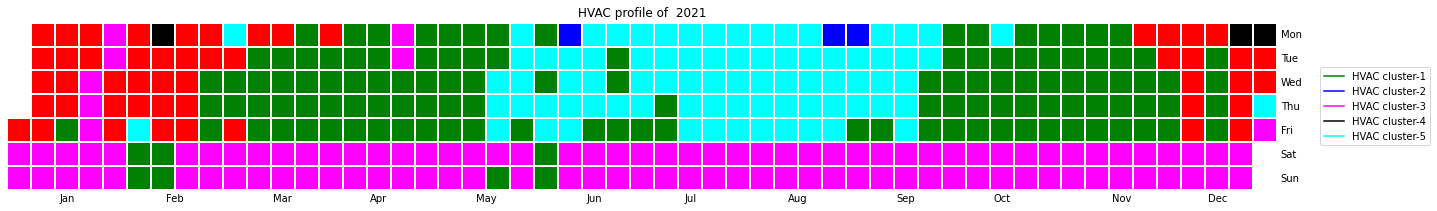

<Figure size 432x288 with 0 Axes>

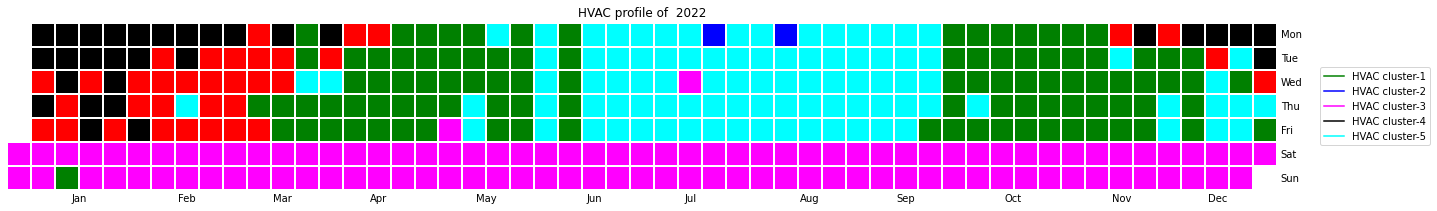

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 1728x1152 with 0 Axes>

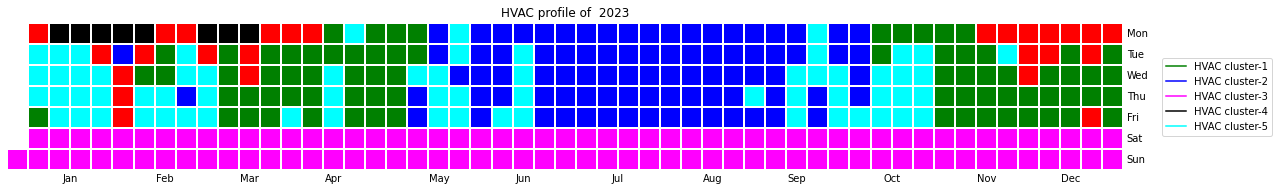

In [161]:
#Colmap for HVAC
from matplotlib import colors

#Heat mape for 2023
# The colors and labels could be used from elsewhere as long as they are of the same size
# cm_colors = [ 'green','magenta','black','cyan','silver','red','yellow']
# cm_labels = ['Moderate weather consumption', 'Holiday and weekend','Winter start of the weekdays consumption', 'Cooling priod consumption' ,
#              'Outliers','After COVIV19 winter consumption',' During COVIV19 winter consumption']
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
#calmap.yearplot(events, year=2021, cmap=cmap, vmin=events.min(), vmax=events.max(), linewidth=0.3, ax=ax)
calmap.yearplot(eventsHVAC, year=2021, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])
    

# ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,3,4]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('HVAC profile of  2021')
fig.tight_layout()


#Heat mape for 2022
plt.figure()
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsHVAC, year=2022, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,3,4]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('HVAC profile of  2022')
fig.tight_layout()


#Heat mape for 2023
plt.figure()
plt.figure()
cm_colors = ['green','blue','magenta','black','cyan','red']
cm_labels = ['HVAC cluster-1', 'HVAC cluster-2','HVAC cluster-3', 'HVAC cluster-4' ,
             'HVAC cluster-5','HVAC cluster-6']
cmap = colors.ListedColormap(cm_colors)
plt.figure(figsize=(24, 16))
fig, ax = plt.subplots(figsize=(20, 12))
calmap.yearplot(eventsHVAC, year=2023, cmap=cmap, vmin=eventsHVAC.min(), vmax=eventsHVAC.max(), linewidth=0.4, ax=ax)
for i in range(len(cm_colors)):
    ax.plot([],[],c=cmap.colors[i],label=cm_labels[i])

handles, labels = plt.gca().get_legend_handles_labels()
order = [0,1,2,3,4]
#ax.legend(bbox_to_anchor=(1.03,0.5), loc='center left')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],bbox_to_anchor=(1.03,0.5), loc='center left')
plt.title('HVAC profile of  2023')

In [107]:
X1=[]  

for i in range(Dayly_Plug_loads_labels2.shape[0]):
    if Dayly_Plug_loads_labels1[i]==1:  
        X1.append(scaled_data_Plug_loads[i])
np.array(X1).shape        
#X1

(109, 24)

In [84]:
mean_all

array([0.5169879 , 0.51416974, 0.51389789, 0.51269874, 0.54213572,
       0.54682871, 0.51787893, 0.55069899, 0.65324925, 0.75241791,
       0.76976399, 0.76926248, 0.76968431, 0.76050729, 0.76014145,
       0.76414445, 0.72297303, 0.68316554, 0.63234593, 0.60252189,
       0.59050302, 0.55381046, 0.54389535, 0.52953245])

In [86]:
Ocu=(mean_all-mean_all.min())/(mean_all.max()-mean_all.min())
Ocu

array([0.01668509, 0.00572228, 0.00466476, 0.        , 0.11451172,
       0.13276773, 0.02015128, 0.14782337, 0.54675031, 0.93252264,
       1.        , 0.99804907, 0.99969004, 0.96399083, 0.9625677 ,
       0.97813962, 0.81798021, 0.66312659, 0.46543508, 0.3494177 ,
       0.30266355, 0.15992718, 0.12135676, 0.06548421])

In [26]:
HVAC.shape

(875, 24)